# CHƯƠNG 2: CHUẨN BỊ VÀ LÀM SẠCH DỮ LIỆU (DATA PREPROCESSING & FEATURE ENGINEERING)

## 2.1. Tình huống dẫn dắt: Hậu quả của hiện tượng "Garbage in, Garbage out" trong mô hình đa biến

Khái niệm "Garbage in, Garbage out" phản ánh một định lý nền tảng trong khoa học dữ liệu và thống kê toán học, nhấn mạnh rằng chất lượng của đầu ra từ bất kỳ một hệ thống phân tích nào đều phụ thuộc tuyệt đối vào chất lượng của dữ liệu đầu vào. Trong bối cảnh phân tích dữ liệu đa biến, nguyên lý này càng thể hiện rõ nét mức độ tàn phá khi các kỹ thuật phức tạp như Structural Equation Modeling - SEM hay Confirmatory Factor Analysis - CFA được áp dụng lên một bộ dữ liệu chứa nhiều khiếm khuyết. Theo Hair et al. (2018) trong chương hai của tác phẩm về phân tích đa biến, một trong những bước mang tính sống còn quyết định sự thành bại của mô hình là quá trình tinh chuẩn dữ liệu, đặc biệt là cách thức đối phó với giá trị khuyết và dữ liệu Outliers. Khi không được nhận diện và xử lý triệt để, những khuyết tật này sẽ phá vỡ toàn bộ cấu trúc hiệp phương sai cơ sở, dẫn đến hiện tượng chệch hướng trong ước lượng tham số và làm sụp đổ hoàn toàn độ tin cậy của các suy luận thống kê. Sự phức tạp gia tăng theo hàm mũ khi nhiều biến số tương tác đồng thời, khiến cho một sai lệch nhỏ ở cấp độ đơn biến có thể khuyếch đại thành một sai lầm thảm họa trong cấu trúc đa biến.

Để minh họa một cách trực quan và sâu sắc cho thảm họa bắt nguồn từ việc phớt lờ các bước làm sạch dữ liệu, chúng ta tiến hành mổ xẻ một tình huống thực tiễn điển hình về sự sụp đổ của một mô hình dự báo tài chính. Một quỹ đầu tư định lượng từng phát triển một hệ thống giao dịch thuật toán phức tạp nhằm dự phóng lợi suất của các tài sản rủi ro dựa trên hàng chục chỉ báo vĩ mô và vi mô. Quá trình thu thập dữ liệu tự động từ nhiều nguồn khác nhau đã vô tình tích lũy một lượng lớn các điểm dữ liệu bị khuyết và những cú sốc giá cực đoan. Thay vì tiến hành nội suy đa biến hoặc áp dụng các kỹ thuật ước lượng hợp lý tối đa, nhóm nghiên cứu lại chọn cách điền khuyết bằng giá trị trung bình đơn giản và bỏ qua hoàn toàn việc nhận diện các điểm dị biệt. Hậu quả là, mô hình đã học được những quy luật giả tạo, dẫn đến hiện tượng Overfitting nghiêm trọng trên tập dữ liệu huấn luyện nhưng lại thất bại thảm hại khi áp dụng vào thực chiến. Cơ chế nội suy thô sơ đã vô tình làm giảm phương sai tự nhiên của dữ liệu và phá vỡ Data Generating Process - DGP gốc, trong khi các điểm Outliers không được kiểm soát đã kéo lệch các đường hồi quy, tạo ra những tín hiệu mua bán hoàn toàn sai lệch. Sự sụp đổ của quỹ đầu tư này là minh chứng đắt giá cho việc ứng dụng các thuật toán tối tân mà bỏ qua nền tảng dữ liệu cơ sở.

Về mặt toán học, sự méo mó do dữ liệu Outliers gây ra có thể được biểu diễn thông qua hàm mục tiêu của phương pháp bình phương tối thiểu hoặc ước lượng hợp lý cực đại. Khi xem xét bài toán hồi quy đa biến cơ bản, véc-tơ hệ số ước lượng được xác định bằng một ma trận chiếu trực giao. Sự hiện diện của một điểm dữ liệu có giá trị đòn bẩy cao sẽ thao túng hoàn toàn véc-tơ này. Ta xem xét công thức hàm khoảng cách Mahalanobis, một công cụ chẩn đoán cốt lõi để phát hiện các cá thể dị biệt trong không gian đa chiều, như được thảo luận bởi Rencher & Christensen (2012). Công thức được định nghĩa như sau:

$$ D^2_i = (\mathbf{x}_i - \boldsymbol{\bar{x}})^T \mathbf{S}^{-1} (\mathbf{x}_i - \boldsymbol{\bar{x}}) $$

Trong đó, $\mathbf{x}_i$ là véc-tơ quan sát thứ $i$, $\boldsymbol{\bar{x}}$ là véc-tơ trung bình mẫu, và $\mathbf{S}$ là ma trận hiệp phương sai mẫu. Ý nghĩa hình học của công thức này là một thước đo khoảng cách từ một điểm dữ liệu cụ thể đến trọng tâm của toàn bộ tập dữ liệu, trong đó không gian khoảng cách đã được chuẩn hóa bởi cấu trúc hiệp phương sai. Thay vì đo bằng khoảng cách Euclid thông thường, khoảng cách Mahalanobis điều chỉnh cho sự tương quan giữa các biến số, tạo ra các đường đồng mức có hình dạng elip. Nếu một điểm nằm ngoài đường đồng mức chi phối, nó sở hữu đòn bẩy khổng lồ và có khả năng bẻ cong các siêu mặt phẳng dự báo. Ứng dụng thực tế trong kinh tế và tài chính của công thức này vô cùng quan trọng đối với các hệ thống cảnh báo rủi ro sớm. Các tổ chức tín dụng sử dụng khoảng cách Mahalanobis để cô lập những giao dịch bất thường mang tính chất gian lận hoặc để nhận diện những doanh nghiệp có cấu trúc tài chính dị biệt so với mặt bằng chung của ngành. Trong kịch bản quỹ đầu tư thuật toán nêu trên, nếu nhóm phân tích tính toán chuẩn xác tham số này cho từng mốc thời gian, họ đã có thể loại bỏ hoặc hạ trọng số của những phiên giao dịch có sự biến động mang tính chất cú sốc hệ thống, từ đó bảo vệ véc-tơ tham số khỏi sự thao túng của các giá trị cực đoan.

Bên cạnh tác động của các điểm dị biệt, sai lầm chết người thứ hai trong kịch bản tài chính này xuất phát từ phương pháp xử lý dữ liệu khuyết. Việc điền khuyết bằng giá trị trung bình là một hành động triệt tiêu phương sai và gây nhiễu loạn nghiêm trọng cấu trúc tương quan. Theo Johnson & Wichern (2007), khi quan sát dữ liệu với các khuyết tật theo cơ chế Missing Completely At Random hoặc Missing At Random, việc chèn một hằng số vào các ô trống sẽ làm co cụm đám mây điểm dữ liệu về phía tâm. Ta có thể định lượng mức độ suy giảm phương sai qua công thức phương sai mẫu sau khi nội suy bằng giá trị trung bình:

$$ \tilde{s}^2_j = \frac{n_{obs} - 1}{n - 1} s^2_{obs, j} $$

Trong đó, $\tilde{s}^2_j$ là phương sai biến đổi của biến $j$ sau khi điền khuyết, $n_{obs}$ là số lượng quan sát thực tế có sẵn, $n$ là tổng kích thước mẫu, và $s^2_{obs, j}$ là phương sai ban đầu của các giá trị quan sát được. Ý nghĩa hình học của công thức này là một phép thu nhỏ quy mô phân tán dọc theo trục tọa độ của biến $j$. Vì $n_{obs}$ nhỏ hơn $n$, hệ số nhân nhỏ hơn một, khiến cho hình chiếu của tập dữ liệu lên trục này bị co rút lại. Đám mây điểm đa chiều mất đi hình dáng nguyên bản, các elipsoid biểu diễn sự phân phối chung bị bóp méo, làm cho góc giữa các véc-tơ đặc trưng thay đổi. Ứng dụng thực tế trong kinh tế và tài chính của sự co rút phương sai này mang đến những hậu quả khôn lường trong việc định lượng mức bù rủi ro và xây dựng danh mục đầu tư. Phương sai và độ lệch chuẩn là đại diện trực tiếp cho rủi ro. Khi mô hình định giá chẩn đoán sai phương sai do dữ liệu đã bị san phẳng một cách nhân tạo, hệ thống sẽ đánh giá thấp mức độ rủi ro thực tế của các tài sản tài chính. Điều này kích hoạt hiện tượng phân bổ vốn quá mức vào các tài sản nguy hiểm. Trong ví dụ về quỹ định lượng, hệ thống đã ảo tưởng về một biên độ an toàn giả tạo do phương sai bị nén lại, dẫn tới việc tối ưu hóa sai lệch và chịu thiệt hại nặng nề khi các biến động dữ dội xảy ra trên nền tảng giao dịch thực tiễn.

Sự tương tác cộng gộp giữa các điểm Outliers không được kiểm soát và dữ liệu khuyết bị nội suy sai lệch làm trầm trọng thêm nhiều vấn đề cấu trúc khác, điển hình là Multicollinearity. Khi nhiều chuỗi thời gian tài chính bị khuyết ở những giai đoạn khủng hoảng và cùng được điền bằng các giá trị trung bình, chúng vô tình chia sẻ chung một hình mẫu biến động nhân tạo tĩnh lặng. Tính chất này làm tăng mức độ phụ thuộc tuyến tính giữa các biến giải thích, khiến cho ma trận thông tin trở nên gần như suy biến. Việc tính toán nghịch đảo ma trận trong các thuật toán ước lượng sẽ tạo ra các hệ số hồi quy có sai số chuẩn khổng lồ, dao động mạnh mẽ chỉ với một thay đổi vô cùng nhỏ trong mẫu dữ liệu mới. Sự bất ổn định này phá hủy hoàn toàn Stationarity - Stationarity của chuỗi dữ liệu, một giả định tiên quyết cho bất kỳ mô hình dự phóng dài hạn nào. Một chuỗi dữ liệu vốn dĩ tuân theo các quy luật tích hợp bậc một nhưng lại bị chèn ép các giá trị trung bình cố định sẽ tạo ra những cú sốc cấu trúc giả mạo, đánh lừa các kiểm định nghiệm đơn vị. Thay vì phản ánh những động lực vĩ mô thực chất, các hệ số ước lượng chỉ đang cố gắng uốn nắn đường cong nhằm vừa vặn với các nhiễu loạn được đưa vào một cách nhân tạo. Khi đối mặt với những dữ liệu mới trong tương lai, hiện tượng Data Leakage ngầm định từ quá trình điền khuyết dựa trên toàn tập dữ liệu lịch sử sẽ bộc lộ điểm yếu, khiến cho mức độ dự báo trượt dốc không phanh. Việc hệ thống nhầm lẫn giữa tín hiệu cốt lõi và tiếng ồn do chính người thiết kế vô tình tạo ra đã tước đoạt toàn bộ năng lực tự điều chỉnh của mô hình trước những biến động thực tế.

Mở rộng lăng kính phân tích sang các cấu trúc bậc cao như Measurement Model, nơi các Latent Variables được cấu thành từ hàng loạt các biến quan sát, thảm họa dữ liệu đầu vào còn mang sức công phá lớn hơn. Các chỉ báo như Composite Reliability hay Average Variance Extracted được thiết kế để đánh giá độ tin cậy và sự hội tụ của các nhân tố ẩn, đảm bảo rằng mỗi bộ phận cấu thành đều đóng góp ý nghĩa thực chất vào Latent Variables. Khi tồn tại các giá trị Outliers gây chệch hệ số hiệp phương sai, hệ số Factor Loading của các biến quan sát sẽ bị thao túng, tạo ra những mối liên kết thống kê cực kỳ mạnh mẽ nhưng hoàn toàn vô nghĩa về mặt lý thuyết. Các câu hỏi khảo sát tâm lý hành vi nhà đầu tư hoặc các chỉ số định lượng về niềm tin tài chính nếu chứa đựng những câu trả lời cực đoan chưa qua sàng lọc, sẽ dẫn đến những kết luận sai trái về trạng thái tâm lý bầy đàn. Theo quy trình Exploratory Factor Analysis - EFA, ma trận tương quan bị làm bẩn sẽ sinh ra số lượng nhân tố ẩn sai lệch, phân nhóm các biến số không có sự liên hệ hữu cơ vào cùng một khía cạnh đo lường. Tiếp nối sai lầm đó, việc áp dụng Confirmatory Factor Analysis - CFA nhằm kiểm định giả thuyết cấu trúc sẽ cung cấp những chỉ số phù hợp mô hình hoàn toàn ảo tưởng, tạo ra một vỏ bọc khoa học tinh vi che đậy cho những kết luận vô giá trị. Toàn bộ nền tảng lý thuyết và định giá bị lung lay tận gốc rễ bởi những sai lầm thô sơ ngay từ khâu tiền xử lý. Khi bước sang giai đoạn đánh giá các tác động nhân quả thông qua Structural Equation Modeling - SEM, những ước lượng đường dẫn sẽ không còn phản ánh dòng chảy của thông tin kinh tế thực, mà chỉ là biểu hiện hệ thống của một cơ sở dữ liệu đã hỏng hóc.

Khía cạnh tiếp theo bị tổn thương nghiêm trọng trong cấu trúc mô hình chính là sự cân bằng toán học tinh tế giữa độ chệch và phương sai, thường được biết đến dưới khái niệm Bias-Variance Tradeoff. Một mô hình được xây dựng trên bộ dữ liệu ô nhiễm không chỉ đánh mất tính chính xác mà còn phá vỡ triệt để các định lý tối ưu cơ sở. Khi một biến số chứa quá nhiều giá trị khuyết bị loại bỏ hoàn toàn khỏi mô hình thay vì được xử lý bằng các kỹ thuật nội suy tinh vi, mô hình ngay lập tức đối mặt với vấn nạn Omitted Variable Bias - OVB. Sự vắng mặt của một biến giải thích trọng yếu sẽ đẩy toàn bộ sức mạnh giải thích của nó sang cho phần dư hoặc các biến còn lại, làm thiên lệch các hệ số hồi quy. Công thức định lượng sự Omitted Variable Bias được thể hiện bằng phương trình kỳ vọng của hệ số hồi quy sai lệch:

$$ E(\hat{\boldsymbol{\beta}}_{restricted}) = \boldsymbol{\beta}_1 + \mathbf{A} \boldsymbol{\beta}_2 $$

Trong đó, $\hat{\boldsymbol{\beta}}_{restricted}$ là véc-tơ hệ số ước lượng khi bỏ sót tập biến trọng yếu, $\boldsymbol{\beta}_1$ là hệ số thực của các biến được đưa vào, $\boldsymbol{\beta}_2$ là hệ số của tập biến bị bỏ sót, và $\mathbf{A}$ là ma trận chuyển chiếu phản ánh sự tương quan giữa các biến có mặt và các biến bị loại trừ. Ý nghĩa hình học của công thức này là sự bóp méo hình chiếu của véc-tơ mục tiêu lên không gian con do các biến giải thích tạo ra. Khi không gian con bị thu hẹp do loại bỏ một chiều dữ liệu thiết yếu, góc chiếu thay đổi, khiến cho véc-tơ hệ số phải tự kéo dài hoặc co ngắn lại một cách giả tạo để bù đắp cho sự thiếu hụt chiều không gian đó, dẫn đến một góc sai lệch vĩnh viễn không thể hội tụ về giá trị thực. Ứng dụng thực tế trong kinh tế và tài chính được thể hiện rõ ràng qua bài toán xác định các nhân tố cấu thành lợi nhuận doanh nghiệp. Nếu biến số về chỉ số năng lực quản trị bị loại bỏ vì có quá nhiều dữ liệu khuyết, sức mạnh giải thích của nó sẽ bị gán ghép sai lệch sang các biến tài chính truyền thống như tỷ lệ đòn bẩy hoặc biên lợi nhuận. Điều này dẫn đến việc các nhà phân tích định giá cao một cách phi lý các chỉ số tài chính ngắn hạn, trong khi bỏ qua rủi ro tiềm ẩn từ lỗ hổng quản trị. Hệ quả là việc đưa ra các khuyến nghị đầu tư sai lầm, phá hủy tài sản của cổ đông trong trung và dài hạn.

Trong kỷ nguyên hiện đại, khi các cấu trúc thống kê học đa biến được tích hợp sâu rộng vào các hệ thống học máy phức tạp, hậu quả của việc dung nạp dữ liệu rác càng trở nên tàn khốc và khó theo dõi hơn bao giờ hết. Những kỹ thuật giải thích mô hình như Explainable AI - XAI cố gắng bóc tách cơ chế ra quyết định của các thuật toán hộp đen, phân bổ trọng số đóng góp cho từng tính năng đầu vào. Tuy nhiên, khi bản thân nền tảng dữ liệu đã bị làm sai lệch bởi các giá trị Outliers chưa được kiểm soát và các phương pháp điền khuyết ngây ngô, những lời giải thích từ XAI cũng sẽ chỉ là sự biện minh sắc sảo cho một hệ thống hỏng hóc. Công cụ giải thích có thể chỉ ra một cách đầy tự tin rằng mô hình phụ thuộc cực kỳ mạnh mẽ vào một biến số vĩ mô cụ thể, nhưng thực chất sự phụ thuộc thống kê đó chỉ là kết quả ngẫu nhiên của một vài điểm đòn bẩy khổng lồ đang giật dây toàn bộ hệ thống tham số. Sự minh bạch trong kịch bản phân tích này chỉ là một ảo ảnh nhận thức. Nó trao cho người sử dụng một niềm tin sai lệch rằng họ đang thấu hiểu sâu sắc cơ chế tài chính của nền kinh tế, trong khi thực tế họ đang chiêm ngưỡng một tập hợp các nhiễu loạn ngẫu nhiên được khuếch đại qua các hàm kích hoạt phi tuyến tính. Quá trình ra quyết định dựa trên những kiến giải độc hại này sẽ dẫn các tổ chức tài chính vào những cái bẫy thanh khoản vô hình, nơi rủi ro thực sự bị che lấp bởi những con số định lượng mang vỏ bọc khoa học hoàn hảo.

Tổng hợp lại các quan điểm phân tích từ Hair et al. (2018), việc sàng lọc và xử lý dữ liệu không phải là một công đoạn kỹ thuật nhàm chán mang tính thủ tục, mà là một bước thiết kế hệ thống mang tính chiến lược quyết định. Nhóm tác giả nhấn mạnh rằng nhà nghiên cứu cần thiết lập những ranh giới nghiêm ngặt đối với dữ liệu trước khi bất kỳ một thuật toán đa biến nào được kích hoạt. Thay vì vội vã đưa dữ liệu vào các phần mềm thống kê để tìm kiếm những hệ số có ý nghĩa đẹp mắt, công việc thực sự của một nhà khoa học dữ liệu là phải đắm chìm vào các kỹ thuật phân tích phần dư, rà soát khoảng cách đa chiều và thực hiện các phép thử nội suy chuyên sâu. Đối với kịch bản quỹ đầu tư thuật toán đã đề cập, nếu họ áp dụng các cơ chế nội suy kỳ vọng tối đa đa biến kết hợp cùng thuật toán lọc nhiễu, họ đã có thể bảo toàn được nền tảng cơ sở. Chỉ khi dữ liệu đầu vào phản ánh đúng cấu trúc hữu cơ của thực tại kinh tế, các kỹ thuật phân tích tối tân mới có thể phát huy giá trị chân chính của chúng. Sự cẩu thả trong giai đoạn tiền xử lý không đơn thuần làm giảm độ chính xác, mà nó thao túng toàn bộ hệ thống suy luận, biến các nỗ lực mô hình hóa thành những quả bom nổ chậm trong hệ thống phân tích định lượng.


## 2.2. Xử lý Dữ liệu khuyết thiếu (Missing Data) và Outliers (Outliers)

Cơ sở lý thuyết của phân tích đa biến phụ thuộc sâu sắc vào tính toàn vẹn của tập hợp dữ liệu đầu vào. Dữ liệu khuyết thiếu và các điểm Outliers không chỉ đơn thuần là những khiếm khuyết kỹ thuật hay những hiện tượng nhiễu ngẫu nhiên, mà chúng còn phản ánh trực tiếp những đứt gãy trong quá trình Data Generating Process - DGP. Dưới lăng kính của thống kê toán học, một ma trận dữ liệu hoàn hảo hiếm khi tồn tại trong thực tiễn. Những khoảng trống thông tin và những giá trị dị biệt văng xa khỏi khối tâm phân phối chứa đựng những hàm ý sâu xa về cấu trúc ẩn của hệ thống. Theo quan điểm của Hair et al. (2018), việc lờ đi hoặc xử lý sai lệch hai vấn đề này sẽ lập tức dẫn đến Omitted Variable Bias - OVB, làm sai lệch nghiêm trọng các tham số ước lượng. Trong các hệ thống phức tạp, từ kỹ thuật Exploratory Factor Analysis - EFA đến Confirmatory Factor Analysis - CFA hay Structural Equation Modeling - SEM, sự méo mó của ma trận hiệp phương sai do khuyết thiếu và Outliers gây ra có thể phá vỡ hoàn toàn cấu trúc Measurement Model, làm sụt giảm nghiêm trọng các chỉ số độ tin cậy như Composite Reliability và Average Variance Extracted. Do đó, quy trình nhận diện, phân loại và khắc phục các dị tật dữ liệu này đòi hỏi một nền tảng toán học vô cùng nghiêm ngặt, kết hợp giữa lý thuyết xác suất, đại số tuyến tính và tư duy tối ưu hóa đa chiều. Khía cạnh này không chỉ là một khâu tiền xử lý cơ học mà thực chất là bước thiết lập một lăng kính nhận thức chuẩn xác trước khi tiến hành bất kỳ suy diễn thống kê nào. Bias-Variance Tradeoff, hay còn gọi là Bias-Variance Tradeoff, luôn hiện diện rành rẽ trong mọi quyết định thay thế dữ liệu hay cắt bỏ điểm dị biệt. Hơn thế nữa, trong bối cảnh các mô hình phức tạp dễ rơi vào trạng thái Overfitting, việc hiểu rõ bản chất của khuyết thiếu và Outliers sẽ giúp ngăn chặn hiện tượng Data Leakage, đồng thời duy trì được tính Stationarity cần thiết cho các phân tích chuỗi thời gian, và cuối cùng đóng góp vào khả năng giải thích minh bạch của mô hình thông qua lăng kính Explainable AI - XAI.

### 2.2.1. Phân loại và cơ chế Missing Data (MCAR, MAR, MNAR)

Nền tảng của việc phân tích dữ liệu khuyết thiếu được đặt nòng cốt trên khung lý thuyết xác suất do Donald Rubin phát triển, trong đó sự vắng mặt của dữ liệu không được xem là những khoảng trắng vô nghĩa, mà được mô hình hóa như một biến ngẫu nhiên độc lập có quy luật phân phối riêng biệt. Để kiến tạo cấu trúc toán học này, chúng ta định nghĩa ma trận dữ liệu tổng thể là $Y$, bao gồm hai phần cấu thành: phần dữ liệu có thể quan sát được ký hiệu là $Y_{obs}$ và phần dữ liệu bị ẩn khuất ký hiệu là $Y_{mis}$. Đồng thời, một ma trận chỉ báo khuyết thiếu $R$ được thiết lập, trong đó phần tử $R_{ij} = 1$ nếu giá trị tương ứng trong $Y$ bị khuyết, và $R_{ij} = 0$ nếu giá trị đó được quan sát đầy đủ. Toàn bộ hành vi của sự khuyết thiếu được quyết định bởi một hàm phân phối xác suất có điều kiện, phụ thuộc vào một tập hợp tham số vô hướng $\xi$. Từ nền tảng này, Rubin chia cơ chế khuyết thiếu thành ba phân lớp mang tính thứ bậc nghiêm ngặt.

Đầu tiên là cơ chế khuyết thiếu hoàn toàn ngẫu nhiên, được giới học thuật định danh là Missing Completely At Random (MCAR). Dưới cơ chế này, xác suất xảy ra sự khuyết thiếu hoàn toàn độc lập với cả phần dữ liệu đã quan sát được lẫn phần dữ liệu bị ẩn đi. Xét về mặt biểu diễn toán học, cơ chế này được định nghĩa qua phương trình xác suất: 
$$P(R | Y_{obs}, Y_{mis}, \xi) = P(R | \xi)$$
Về khía cạnh ý nghĩa hình học, công thức này mô tả một không gian trực giao tuyệt đối, nơi mà vector đại diện cho sự khuyết thiếu $R$ nằm trong một mặt phẳng hoàn toàn vuông góc với đa tạp chứa dữ liệu $Y$. Bất kỳ phép chiếu nào của dữ liệu lên không gian khuyết thiếu đều trả về gốc tọa độ, chứng tỏ không tồn tại bất kỳ một cấu trúc tương quan không gian nào giữa việc một điểm dữ liệu biến mất và giá trị tọa độ của chính nó. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, cơ chế MCAR đại diện cho những tình huống mất mát thông tin mang tính chất thuần túy cơ học. Một ví dụ điển hình là khi một nhân viên ngân hàng vô tình làm rơi mất một tập hồ sơ khách hàng, hoặc khi hệ thống truyền tải dữ liệu của một sàn giao dịch chứng khoán bị đứt cáp quang trong chốc lát, khiến một số mức giá không được ghi nhận. Trong những kịch bản như vậy, việc dữ liệu bị mất không hề mang theo bất kỳ tín hiệu tiềm ẩn nào về mức thu nhập của khách hàng hay xu hướng tăng giảm của mã cổ phiếu.

Cấp độ phức tạp thứ hai trong hệ thống phân loại của Rubin là cơ chế Missing at Random, được viết tắt là Missing at Random (MAR). Đây là một thuật ngữ thường gây hiểu lầm, bởi vì sự khuyết thiếu ở đây không hề ngẫu nhiên theo nghĩa tuyệt đối, mà nó phụ thuộc một cách có hệ thống vào những biến số khác đã được quan sát thành công. Khía cạnh này thiết lập một cấu trúc phụ thuộc có điều kiện vô cùng tinh tế. Xét về mặt biểu diễn toán học, cơ chế MAR được mô tả thông qua phương trình: 
$$P(R | Y_{obs}, Y_{mis}, \xi) = P(R | Y_{obs}, \xi)$$
Về khía cạnh ý nghĩa hình học, công thức này ám chỉ rằng đa tạp mô tả trạng thái khuyết thiếu hoàn toàn được bao hàm bên trong không gian con được chiếu từ các biến quan sát $Y_{obs}$. Nếu chúng ta có thể vẽ ra một hệ tọa độ đa chiều, hình chiếu của sự mất mát dữ liệu hoàn toàn trùng khớp với bóng của các chiều không gian mà chúng ta đã nắm bắt được, do đó không có thông tin hình học nào bị rò rỉ ra ngoài vùng không gian chưa biết. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, cơ chế MAR giải thích cho những hiện tượng rất phổ biến trong quản lý rủi ro tín dụng. Lấy ví dụ trong các hồ sơ xin vay vốn, xác suất một khách hàng không khai báo mức thu nhập phụ thuộc rất lớn vào độ tuổi và nghề nghiệp của họ (hai biến số đã được quan sát). Những người làm nghề tự do thường có xu hướng bỏ trống ô thu nhập nhiều hơn những người làm việc hưởng lương cố định. Bởi vì đặc tính nghề nghiệp và độ tuổi đã được thu thập đầy đủ, hệ thống hoàn toàn có thể dựa vào đó để nội suy ra mô hình khuyết thiếu mà không bị rơi vào bẫy Omitted Variable Bias - OVB. Tuy nhiên, nếu xử lý sai lệch cơ chế MAR, nhà phân tích rất dễ gây ra Data Leakage khi thông tin dự báo bị rò rỉ qua các quy trình điền khuyết thiếu cẩn trọng, làm hỏng hoàn toàn độ tin cậy của mô hình học máy.

Mức độ thách thức lớn nhất và cũng là cơ chế khó đối phó nhất chính là khuyết thiếu không ngẫu nhiên, hay Missing Not At Random (MNAR). Trong kịch bản khốc liệt này, bản thân giá trị của điểm dữ liệu bị khuyết lại chính là nguyên nhân trực tiếp dẫn đến sự vắng mặt của nó. Trạng thái này phá vỡ toàn bộ các giả định đẳng hướng và tuyến tính cơ bản. Xét về mặt biểu diễn toán học, cơ chế MNAR được định nghĩa khi phương trình xác suất không thể bị giản lược, giữ nguyên dạng phụ thuộc vào biến chưa quan sát: 
$$P(R | Y_{obs}, Y_{mis}, \xi) = f(Y_{mis}, Y_{obs}, \xi)$$
Về khía cạnh ý nghĩa hình học, công thức này minh họa cho một vector khuyết thiếu có góc hợp với trục tọa độ của dữ liệu ẩn $Y_{mis}$ khác 90 độ, tạo ra một hình chiếu khác không (non-zero projection) lên chiều không gian vô hình. Điều này khiến cho bề mặt giới hạn của đa tạp dữ liệu bị bóp méo thành những hình thù không đối xứng, làm dịch chuyển khối tâm phân phối ra khỏi vị trí kỳ vọng thực sự. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, MNAR hiện diện như một bóng ma trong các cuộc khảo sát sự giàu có hoặc các báo cáo minh bạch doanh nghiệp. Những cá nhân có tài sản cực kỳ khổng lồ thường cố tình từ chối trả lời các câu hỏi về giá trị ròng của họ nhằm né tránh sự chú ý của cơ quan thuế. Tương tự, các quỹ đầu tư đang gánh chịu khoản lỗ trầm trọng thường trì hoãn hoặc giấu giếm báo cáo lợi nhuận hàng quý. Chính sự yếu kém về hiệu suất tài chính lại là nguyên nhân trực tiếp khiến dữ liệu về hiệu suất đó biến mất. Việc giải quyết MNAR bắt buộc phải sử dụng đến các Latent Variables trong cấu trúc Structural Equation Modeling - SEM để mô phỏng lại Data Generating Process - DGP nguyên thủy, nếu không, toàn bộ các suy luận về nền kinh tế sẽ bị méo mó nghiêm trọng.

### 2.2.2. Các phương pháp thay thế dữ liệu (Imputation Methods)

Sau khi định vị được cơ chế vận hành của dòng dữ liệu khuyết thiếu, nhiệm vụ phân tích đa biến bắt buộc phải chuyển sang giai đoạn phục dựng lại cấu trúc thông nguyên bản thông qua các kỹ thuật thay thế (Imputation Methods). Việc sử dụng các biện pháp thô sơ như xóa bỏ danh sách (listwise deletion) hoặc xóa bỏ từng cặp (pairwise deletion) thường dẫn đến những thảm họa toán học, đặc biệt là hiện tượng ma trận hiệp phương sai mất đi tính xác định dương (non-positive definite), từ đó đánh sập hoàn toàn thuật toán ước lượng trong Confirmatory Factor Analysis - CFA. Do đó, các nhà thống kê đã phát triển một phổ các phương pháp bù đắp dữ liệu từ đơn giản đến cực kỳ phức tạp nhằm bảo toàn cấu trúc cấu thành của ma trận phân tích.

Phương pháp khởi thủy và mang tính trực giác nhất là điền khuyết bằng giá trị trung bình (Mean Imputation). Thuật toán này quét qua toàn bộ cột dữ liệu bị thiếu và điền vào đó giá trị trung tâm của những quan sát khả dụng. Xét về mặt biểu diễn toán học, quá trình này được đặc tả bởi phương trình: 
$$\hat{y}_{ij} = \frac{1}{N_{obs}} \sum_{k \in \Omega_{obs}} y_{kj}$$
Về khía cạnh ý nghĩa hình học, công thức này ép buộc tất cả các điểm dữ liệu lơ lửng trong không gian nhiều chiều phải trượt dọc theo trục tọa độ bị thiếu để hội tụ đồng loạt về phía siêu mặt phẳng trung tâm (centroid hyperplane). Hành động này tuy duy trì được khối tâm chung nhưng lại phá hủy hoàn toàn thể tích không gian phân tán, làm co rút mạnh mẽ độ trải rộng của các vector dữ liệu. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, điền khuyết bằng giá trị trung bình đôi khi được áp dụng trong việc tính toán các bộ chỉ số giá hàng hóa cơ bản, nơi mà một vài mặt hàng bị mất báo giá trong ngày sẽ được tạm thời thay thế bằng mức giá bình quân của toàn bộ rổ hàng hóa. Dù vậy, phương pháp này che giấu đi sự biến động thực sự, gây suy giảm phương sai một cách giả tạo và trực tiếp phá vỡ sự cân bằng của Bias-Variance Tradeoff, dẫn đến hiện tượng đánh giá quá cao mức độ ổn định của rổ tài sản.

Nhằm khắc phục nhược điểm mất mát phương sai, kỹ thuật điền khuyết dựa trên mô hình hồi quy ngẫu nhiên (Stochastic Regression Imputation) được ra đời. Thay vì dùng một hằng số duy nhất, phương pháp này tận dụng mối tương quan giữa các biến để dự phóng ra giá trị tiềm năng, sau đó cộng thêm một lượng nhiễu ngẫu nhiên nhằm phục hồi sự đa dạng tự nhiên. Xét về mặt biểu diễn toán học, mô hình này được biểu thị qua phương trình: 
$$\hat{y}_i = \hat{\beta}_0 + \mathbf{x}_i^T \hat{\boldsymbol{\beta}} + \epsilon_i \quad \text{với} \quad \epsilon_i \sim N(0, \hat{\sigma}^2)$$
Về khía cạnh ý nghĩa hình học, công thức này không đơn thuần chiếu điểm khuyết thiếu xuống siêu mặt phẳng hồi quy, mà nó còn thiết lập một cơ chế nảy ngẫu nhiên (random jitter) dọc theo vector trực giao của mặt phẳng đó. Cấu trúc nhiễu $\epsilon_i$ giúp khôi phục lại đám mây bao quanh đường thẳng trung tâm, tái tạo lại hình dáng khối ellipsoid của ma trận hiệp phương sai. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, kỹ thuật này tỏa sáng trong bài toán định giá bất động sản hàng loạt. Khi một căn hộ bị khuyết thông tin về giá bán, hệ thống sẽ sử dụng diện tích, số phòng ngủ, và tọa độ địa lý (các biến $\mathbf{x}_i$) để nội suy ra mức giá nền tảng, sau đó cộng thêm một sai số ngẫu nhiên đặc trưng cho sự biến động giá của khu vực đó. Điều này giúp hệ thống mô phỏng chính xác tính Stationarity của chuỗi dữ liệu giá cả, tránh việc tạo ra những đường cong dự báo phẳng lặng phi thực tế.

Đối diện với cấu trúc khuyết thiếu đa chiều, phương pháp tối ưu hóa cực đại kỳ vọng (Expectation-Maximization Algorithm - EM) vươn lên như một tiêu chuẩn vàng trong thống kê toán học hiện đại. Thuật toán EM hoạt động như một cỗ máy lặp vòng kín, liên tục xoay chuyển giữa việc phỏng đoán giá trị khuyết và việc tinh chỉnh tham số mô hình tổng thể cho đến khi hệ thống đạt trạng thái cân bằng lượng giác. Xét về mặt biểu diễn toán học, bước Kỳ vọng (E-step) của thuật toán được cấu trúc bởi phương trình tích phân hàm log-likelihood có điều kiện: 
$$Q(\boldsymbol{\theta} | \boldsymbol{\theta}^{(t)}) = \int \log L(\boldsymbol{\theta}; Y_{obs}, Y_{mis}) f(Y_{mis} | Y_{obs}, \boldsymbol{\theta}^{(t)}) dY_{mis}$$
Về khía cạnh ý nghĩa hình học, công thức này tương đương với hành trình leo lên một ngọn núi có bề mặt địa hình liên tục biến đổi. Trong đó, hệ thống luân phiên giữa việc đóng băng hình dáng ngọn núi để tìm ra hướng đi dốc nhất (E-step định hình đa tạp không gian) và việc bước lên điểm cao nhất trên hướng đi đó (M-step cực đại hóa tọa độ). Quá trình này giúp thuật toán trượt trên bề mặt của hàm hợp lý và chắc chắn hội tụ về điểm cực đại địa phương. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, thuật toán EM là công cụ bất khả chiến bại trong việc tái tạo đường cong lợi suất (yield curve) của trái phiếu khoá bạc khi các kỳ hạn nhất định bị khuyết thanh khoản. Nó có khả năng khai quật các Latent Variables đại diện cho kỳ vọng lạm phát và lãi suất cơ sở, từ đó tái cấu trúc lại toàn bộ cấu trúc kỳ hạn của lãi suất một cách mượt mà và nhất quán về mặt lý thuyết tài chính.

Đỉnh cao của triết lý xử lý dữ liệu khuyết là phương pháp điền khuyết đa phương (Multiple Imputation - MI), được Donald Rubin kiến tạo để giải quyết triệt để vấn đề độ bất định. Thay vì cung cấp một con số cố định duy nhất gây ảo tưởng về tính chính xác, MI tạo ra nhiều kịch bản điền khuyết khác nhau (thường ký hiệu là $m$ kịch bản), phân tích từng kịch bản riêng rẽ, rồi dung hợp lại bằng quy tắc gộp phương sai. Xét về mặt biểu diễn toán học, định lý biến thiên của Rubin được thể hiện qua phương trình tổng phương sai: 
$$V_T = \bar{W} + \left(1 + \frac{1}{m}\right) B$$
Về khía cạnh ý nghĩa hình học, công thức này phá vỡ ranh giới của một điểm kỳ vọng đơn lẻ để tạo ra một vùng mây bất định dạng siêu ellipsoid. Thành phần $\bar{W}$ đo lường kích thước lõi của khối ellipsoid trong từng kịch bản, trong khi thành phần $B$ đo lường khoảng cách dịch chuyển khối tâm giữa các kịch bản khác nhau. Phân số $1/m$ là sự bù đắp không gian cho số lượng mô phỏng hữu hạn. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, phương pháp MI là trái tim của các bài toán kiểm tra sức chịu đựng (Stress Testing) hệ thống ngân hàng. Khi xử lý hồ sơ tín dụng có nhiều dữ kiện tài sản bị thiếu sót, MI sẽ vạch ra vô số các quỹ đạo vỡ nợ khả dĩ. Sự kết hợp giữa biến động nội bộ (khách hàng không trả được nợ) và biến động Outliers (sự không chắc chắn của chính mô hình dự báo) giúp ngân hàng thiết lập được biên độ dự phòng vốn chuẩn xác, tuân thủ nghiêm ngặt các hiệp ước Basel đồng thời tận dụng triệt để nguyên lý Explainable AI - XAI để giải trình rủi ro.

### 2.2.3. Nhận diện Multivariate Outliers bằng khoảng cách Mahalanobis

Khi toàn bộ các khoảng trống thông tin đã được hàn gắn liền mạch, phân tích đa biến phải đối mặt với một cạm bẫy toán học còn nguy hiểm hơn: đó là sự hiện diện của các điểm Outliers đa chiều (Multivariate Outliers). Khác biệt hoàn toàn với Outliers đơn chiều có thể dễ dàng bị bóc trần bằng biểu đồ hộp (boxplot) hay điểm Z-score, Outliers đa chiều là một sinh vật ẩn mình tinh vi trong không gian chéo của các biến số. Một quan sát có thể hoàn toàn bình thường ở từng trục tọa độ riêng lẻ, nhưng lại vi phạm nghiêm trọng cấu trúc tương quan chung của hệ thống. Những điểm dị biệt này bóp méo ma trận hiệp phương sai, làm suy yếu Factor Loading trong các mô hình EFA và phá hủy các suy diễn thống kê chuẩn mực. Để xuyên thủng bức màn ngụy trang này, khoảng cách Mahalanobis được giới thiệu như một thiết bị đo lường không gian tối thượng, có khả năng điều chỉnh sự méo mó của hệ trục tọa độ dựa trên độ phân tán của dữ liệu.

Sự vi diệu của khoảng cách Mahalanobis nằm ở chỗ nó không nhìn không gian bằng lăng kính đẳng hướng của khoảng cách Euclidean, mà nó làm phẳng và đồng nhất hóa độ giãn nở của từng biến số lẫn tương quan giữa chúng. Xét về mặt biểu diễn toán học, bình phương khoảng cách Mahalanobis từ một vector quan sát $\mathbf{x}$ đến vector trung bình $\boldsymbol{\mu}$ được định nghĩa bởi phương trình: 
$$D_M^2(\mathbf{x}) = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})$$
Về khía cạnh ý nghĩa hình học, công thức này thực hiện một phép biến đổi tuyến tính thông qua phân rã Cholesky của ma trận độ chính xác (precision matrix $\boldsymbol{\Sigma}^{-1}$). Phép toán này tương đương với việc cầm một khối mây dữ liệu hình quả dưa hấu (ellipsoid) bóp chặt nó lại dọc theo trục chính và kéo giãn nó ra dọc theo trục phụ cho đến khi nó biến thành một khối cầu hoàn hảo (sphere) có phương sai đồng nhất theo mọi hướng. Khoảng cách Mahalanobis chính là khoảng cách Euclidean thông thường được đo lường trong không gian đã được "cầu hóa" và làm trắng (whitening) này. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, công cụ này là vũ khí chủ lực trong hệ thống phát hiện gian lận thẻ tín dụng. Một giao dịch quẹt thẻ có thể mang số tiền hoàn toàn nằm trong hạn mức bình thường (không phải Outliers đơn chiều), và xảy ra vào khung giờ ban ngày bình thường. Tuy nhiên, sự kết hợp giữa việc "mua trang sức xa xỉ" (biến 1) đi kèm với "mua tại khu vực địa lý cách xa nhà 500km" (biến 2) tạo ra một tổ hợp giao dịch phá vỡ cấu trúc thói quen tiêu dùng đã được định hình. Khoảng cách Mahalanobis sẽ tính toán sự vi phạm tương quan này, lập tức phóng đại giá trị $D_M^2$ và kích hoạt còi báo động gian lận mà không bị đánh lừa bởi bề mặt dữ liệu tẻ nhạt.

Mặc dù mang sức mạnh vượt trội, bản thân phương trình Mahalanobis kinh điển lại ẩn chứa một gót chân Achilles: hiệu ứng che lấp (masking effect). Khi một tập hợp dữ liệu chứa quá nhiều điểm Outliers quy mô lớn, chính những điểm này sẽ kéo lệch vector trung bình $\boldsymbol{\mu}$ và làm phình to ma trận hiệp phương sai $\boldsymbol{\Sigma}$, khiến cho các điểm dị biệt tự hợp thức hóa bản thân và làm giảm giá trị khoảng cách của chính chúng. Để phá vỡ vòng lặp luẩn quẩn này, phương pháp ước lượng hiệp phương sai kháng nhiễu (Robust Covariance Estimation), tiêu biểu là thuật toán Minimum Covariance Determinant (MCD), được áp dụng như một liều thuốc giải độc. Xét về mặt biểu diễn toán học, thuật toán MCD tìm kiếm một tập con $H$ gồm $h$ quan sát (thường là khoảng 50% đến 75% lượng dữ liệu) sao cho định thức của ma trận hiệp phương sai là nhỏ nhất: 
$$\hat{\boldsymbol{\Sigma}}_{MCD} = \arg\min_{\boldsymbol{\Sigma}_H, |H|=h} \det(\boldsymbol{\Sigma}_H)$$
Về khía cạnh ý nghĩa hình học, công thức này thực chất là một bài toán tìm kiếm chiếc vỏ bọc (envelope) chặt chẽ nhất. Định thức của ma trận hiệp phương sai tỷ lệ thuận với bình phương thể tích của khối ellipsoid bao quanh dữ liệu. Bằng cách vứt bỏ những điểm lơ lửng ngoài rìa và chỉ tập trung tối thiểu hóa thể tích của lõi dữ liệu cốt lõi, thuật toán tạo ra một hình ellipsoid đậm đặc, sắc nét và hoàn toàn miễn nhiễm với sức hút từ tính của các thiên thạch Outliers trôi dạt xung quanh. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, thuật toán MCD đóng vai trò cốt lõi trong việc thanh lọc danh mục tối ưu hóa tài sản định lượng. Trong những giai đoạn nền kinh tế rơi vào hoảng loạn, hàng loạt cổ phiếu rác biến động điên cuồng sẽ làm sai lệch ma trận hiệp phương sai Markowitz, dẫn đến việc phân bổ vốn sai lầm. Kỹ thuật MCD giúp hệ thống giao dịch tự động loại bỏ những nhiễu loạn từ các hiện tượng sập giá chớp nhoáng (flash crash), giữ vững trục định vị rủi ro gốc của danh mục đầu tư.

Cuối cùng, sau khi đã tính toán được khoảng cách Mahalanobis kháng nhiễu cho toàn bộ không gian quan sát, bước đi quyết định của nhà phân tích là thiết lập một ranh giới toán học rõ ràng để phân định đâu là dữ liệu cốt lõi và đâu là cấu trúc Outliers. Trong điều kiện giả định dữ liệu tuân theo phân phối chuẩn đa chiều, bình phương khoảng cách Mahalanobis sẽ hội tụ về phân phối Chi-bình phương với số bậc tự do đúng bằng số lượng biến quan sát. Xét về mặt biểu diễn toán học, ngưỡng cắt bỏ (cutoff threshold) được thiết lập bởi phương trình ranh giới xác suất: 
$$P(D_M^2 > \chi^2_{p, 1-\alpha}) = \alpha$$
Về khía cạnh ý nghĩa hình học, công thức này vẽ ra một lớp vỏ siêu ellipsoid ở vùng biên của không gian đa chiều, đóng vai trò như một bức tường thành xác suất. Những điểm tọa độ có giá trị rơi vào bên trong lớp vỏ này được xem là cư dân hợp pháp của vương quốc dữ liệu, trong khi bất kỳ điểm nào văng ra bên ngoài bức tường (tức là vượt qua giá trị phân vị $\chi^2$) sẽ bị phân loại một cách dứt khoát là Outliers đa chiều. Bước sang ứng dụng thực tế trong lĩnh vực kinh tế và tài chính, phương trình ranh giới này chính là nền tảng cốt tủy để thiết lập các ngưỡng Value-at-Risk (VaR) trong quản trị rủi ro định chế. Khi một tổ hợp các yếu tố vĩ mô như tỷ giá hối đoái, lãi suất liên ngân hàng và giá dầu thô cùng dao động tạo ra một vector trạng thái có khoảng cách Mahalanobis vượt quá ngưỡng $\chi^2$ tại mức ý nghĩa $\alpha = 0.01$, điều đó phát đi một thông điệp sinh tử rằng hệ thống tài chính đang bước vào một kịch bản biến động ngàn năm có một. Sự kết hợp tinh tế giữa khoảng cách không gian phi tuyến và ngưỡng xác suất Chi-bình phương giúp định lượng hóa những sự kiện Thiên Nga Đen, ngăn chặn triệt để hiện tượng Overfitting khi thiết lập biên độ an toàn, và đảm bảo rằng quy trình Data Generating Process - DGP thực sự phản ánh đúng bản chất cấu trúc kinh tế mà không bị vẩn đục bởi những dư chấn ngẫu nhiên.


Để đo lường khoảng cách của một quan sát đa chiều nhằm xác định Outliers, thay vì sử dụng khoảng cách Euclidean thông thường, người ta thường dùng khoảng cách Mahalanobis. Khác với Euclidean, Mahalanobis tính đến cả phương sai và hiệp phương sai của các biến, giúp chuẩn hóa tỷ lệ và điều chỉnh tương quan. Phương trình khoảng cách Mahalanobis $D^2$ cho một vector quan sát $x$ đối với phân phối có trung bình $\mu$ và ma trận hiệp phương sai $\Sigma$ được định nghĩa như sau:

$$
D^2 = (x - \mu)^T \Sigma^{-1} (x - \mu)
$$

Khoảng cách này tuân theo phân phối Chi-bình phương ($\chi^2$) với số bậc tự do bằng số lượng biến trong không gian đa chiều, từ đó ta có thể dễ dàng thiết lập các ngưỡng tin cậy (như 95% hoặc 99%) để lọc bỏ Outliers một cách có cơ sở thống kê vững chắc.


## 2.3. Kiểm định các giả định thống kê (Assumptions Testing)

### 2.3.1. Tính chuẩn đa biến, tính tuyến tính và phương sai đồng nhất

Trong mọi tiến trình xây dựng và đánh giá các mô hình định lượng đa chiều, việc thẩm định khắt khe các giả định thống kê nền tảng đóng vai trò thiết yếu nhằm bảo vệ tính toàn vẹn của các suy luận khoa học. Dựa theo các công trình phân tích chuyên sâu của Hair cùng các cộng sự (2018) và Johnson & Wichern (2007), toàn bộ quy trình thiết lập mô hình định lượng luôn phải bám sát cấu trúc nguyên thủy của Data Generating Process - DGP. Bất cứ một sự chệch hướng hay sai sót nào trong khâu kiểm định giả định ban đầu đều không đơn thuần chỉ làm giảm thiểu độ chính xác của các tham số, mà còn đẩy toàn bộ hệ thống vào những rủi ro cực kỳ nghiêm trọng. Khi bỏ qua các bước kiểm tra này, nhà phân tích có thể phải đối mặt với trạng thái tiến thoái lưỡng nan liên quan đến sự đánh đổi khốc liệt của Bias-Variance Tradeoff, hoặc tạo ra những hệ quả sai lệch xuất phát từ vấn đề Omitted Variable Bias - OVB. Trong các hệ thống phức hợp đương đại, đặc biệt là khi kết hợp cùng các công cụ Explainable AI - XAI để làm rõ cơ chế ra quyết định của thuật toán, việc tuân thủ triệt để tính chuẩn đa biến, tính tuyến tính và phương sai đồng nhất trở thành tiêu chuẩn vàng bắt buộc. Thao tác này giúp giới chuyên môn bóc tách thành công những tín hiệu thực sự ra khỏi những biến động ngẫu nhiên bao phủ lấy bộ dữ liệu.

Khái niệm trung tâm và đồng thời là hòn đá tảng cho các kỹ thuật thống kê tham số chính là tính chuẩn đa biến (Multivariate Normality). Vượt xa hơn những quy tắc đơn giản về phân phối chuẩn của một biến số cô lập, tính chuẩn đa biến đặt ra đòi hỏi rằng toàn bộ mọi tổ hợp tuyến tính khả thi được tạo ra từ tập hợp các biến khảo sát cũng phải tạo thành một phân phối chuẩn. Tiêu chuẩn khắt khe này bảo đảm rằng các phương pháp phân tích cấu trúc tiềm ẩn (Latent Variables) điển hình như Exploratory Factor Analysis - EFA hay Confirmatory Factor Analysis - CFA có thể vận hành một cách trơn tru, hỗ trợ việc trích xuất các nhân tố cốt lõi đang lẩn khuất dưới hệ thống dữ liệu đồ sộ. Về mặt toán học, hàm mật độ xác suất của một vector ngẫu nhiên $\mathbf{X}$ bao gồm $p$ chiều tuân theo phân phối chuẩn đa biến được định nghĩa bằng một phương trình giải tích vô cùng chặt chẽ:
$$f(\mathbf{x}) = \frac{1}{(2\pi)^{p/2} |\boldsymbol{\Sigma}|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$$
Bên trong cấu trúc giải tích này, ký hiệu $\boldsymbol{\mu}$ đại diện cho vector trung bình định vị trung tâm của toàn bộ phân phối, trong khi $\boldsymbol{\Sigma}$ đóng vai trò là ma trận hiệp phương sai điều hướng và kiểm soát cường độ phân tán của đám mây dữ liệu. Định thức của ma trận này, ký hiệu là $|\boldsymbol{\Sigma}|$, đóng vai trò chuẩn hóa tổng mật độ, bảo đảm rằng tích phân của hàm số trên toàn bộ không gian $p$ chiều luôn có giá trị bằng một tuyệt đối.

Xét dưới lăng kính hình học không gian, phương trình mật độ xác suất này vẽ ra một không gian đa chiều kỳ vĩ, nơi các quỹ đạo đồng mức của xác suất đan xen và hình thành nên những khối siêu elip (hyper-ellipsoids) đồng tâm. Tâm điểm của mạng lưới siêu elip này được neo giữ kiên cố tại tọa độ trung bình $\boldsymbol{\mu}$. Đồng thời, dáng điệu phình to hay thu hẹp và hướng vươn của những khối siêu elip này được quyết định hoàn toàn bởi kiến trúc bên trong của ma trận hiệp phương sai $\boldsymbol{\Sigma}$. Cụ thể, các giá trị riêng (eigenvalues) của ma trận sẽ ấn định độ dài của các bán trục không gian, còn các vector riêng (eigenvectors) sẽ đảm nhận việc xoay khối elip theo đúng phương hướng phân tán chính. Bất kỳ một sự biến dạng nào tạo ra các vùng lồi lõm phi đối xứng đều là tín hiệu báo động tính chuẩn đa biến đã bị phá vỡ hoàn toàn.

Phóng chiếu hệ thống lý thuyết này vào bối cảnh tài chính và kinh tế vĩ mô, tính chuẩn đa biến hoạt động như một trụ cột vững chãi chống đỡ cho lý thuyết tối ưu hóa danh mục đầu tư Markowitz. Những nhà thiết kế danh mục phải giả định rằng tỷ suất sinh lời của một rổ tài sản cùng nhau tạo thành một mạng lưới phân phối chuẩn đa biến, từ đó cấp phép cho họ dùng ma trận hiệp phương sai để định lượng mức rủi ro tổng thể. Mặc dù vậy, khi không gian giao dịch chứng khoán xuất hiện những đợt rung lắc dữ dội gây ra hiệu ứng đuôi béo (fat tails) và bẻ gãy cấu trúc siêu elip, các mô hình này sẽ vô tình đánh giá thấp rủi ro của các kịch bản thiên nga đen. Điều này bắt buộc các chuyên gia định lượng phải tiến hành nhiều vòng kiểm định nghiêm ngặt để đảm bảo rằng kiến trúc lõi của thông tin không bị méo mó.

Một công cụ toán học mang tính cách mạng để đo lường và thẩm định tính chuẩn đa biến chính là khoảng cách Mahalanobis. Hoàn toàn khác biệt với thước đo Euclid cổ điển vốn dĩ đối xử bình đẳng với mọi hướng trong không gian, khoảng cách Mahalanobis tỏ ra tinh vi hơn hẳn khi tự động điều chỉnh tỷ lệ đo đạc dựa trên ma trận hiệp phương sai. Thước đo này tính toán khoảng cách từ một điểm quan sát cá biệt đến tọa độ trọng tâm, đồng thời có xem xét đến mức độ co giãn và độ nghiêng của tập hợp siêu elip. Phương trình toán học biểu diễn bình phương khoảng cách Mahalanobis cho một điểm dữ liệu $\mathbf{x}_i$ được trình bày như sau:
$$D^2_i = (\mathbf{x}_i - \bar{\mathbf{x}})^T \mathbf{S}^{-1} (\mathbf{x}_i - \bar{\mathbf{x}})$$
Đại lượng $\bar{\mathbf{x}}$ đóng vai trò là vector trung bình mẫu, trong khi $\mathbf{S}^{-1}$ là nghịch đảo của ma trận hiệp phương sai mẫu. Sự góp mặt của ma trận nghịch đảo chính là yếu tố giải quyết triệt để sự bất cân xứng của các chiều không gian độc lập.

Về mặt ý nghĩa hình học, khoảng cách Mahalanobis đóng vai trò như một phép biến đổi làm trắng dữ liệu (whitening transformation). Bằng cách nhân với $\mathbf{S}^{-1}$, thước đo này bóp méo không gian chứa các siêu elip đồng mức và ép chúng trở lại thành các khối siêu cầu tiêu chuẩn. Những điểm quan sát trôi dạt dọc theo phương hướng có dao động lớn sẽ bị thu ngắn khoảng cách lại, trong khi những điểm nằm ở phương hướng có dao động nhỏ sẽ bị khuếch đại lên. Sự điều chỉnh này dọn đường cho một hệ quy chiếu cực kỳ công bằng, nơi mọi sai lệch đều được đánh giá dựa trên mức độ bất thường của nó so với xu hướng phân tán chung, thay vì chỉ xét đến độ dài tọa độ đơn thuần.

Trong hoạt động ngân hàng và hệ thống phòng chống rửa tiền, khoảng cách Mahalanobis được trọng dụng như một radar quét lỗi sắc bén. Bằng cách quan sát tập hợp các biến số như khối lượng tiền lưu chuyển, tần suất rút tiền và mạng lưới vị trí địa lý, các hệ thống tự động tính toán giá trị $D^2_i$ cho từng hành động giao dịch. Dưới giả định tính chuẩn đa biến, đại lượng khoảng cách này sẽ tuân thủ phân phối Chi-bình phương với $p$ bậc tự do ($D^2_i \sim \chi^2_p$). Những giao dịch sở hữu khoảng cách Mahalanobis vượt khỏi giới hạn tới hạn của phân phối sẽ ngay lập tức bị khoanh vùng thành điểm dị biệt (outlier). Trong quá trình tinh chỉnh mô hình Structural Equation Modeling - SEM, việc thanh lọc những điểm dữ liệu cực đoan này là bước phòng ngự thiết yếu để gìn giữ sự bền vững của cấu trúc đo lường (Measurement Model), qua đó ngăn chặn sự xâm nhập của Data Leakage làm nhiễu loạn tham số mục tiêu.

Nhằm thiết lập một góc nhìn toàn vẹn hơn, phương pháp kiểm định Mardia đưa ra bộ tiêu chuẩn dựa trên độ xiên đa biến (multivariate skewness) và độ nhọn đa biến (multivariate kurtosis). Độ xiên đa biến khảo sát tính đối xứng tổng thể của đám mây dữ liệu. Thống kê độ xiên đa biến của tập mẫu, ký hiệu là $b_{1,p}$, được xác lập bởi công thức giải tích tinh vi:
$$b_{1,p} = \frac{1}{n^2} \sum_{i=1}^n \sum_{j=1}^n \left[ (\mathbf{x}_i - \bar{\mathbf{x}})^T \mathbf{S}^{-1} (\mathbf{x}_j - \bar{\mathbf{x}}) \right]^3$$
Công thức này là tổng tập hợp lập phương của mọi khoảng cách chéo đã được chuẩn hóa giữa mọi cặp điểm dữ liệu bên trong không gian $p$ chiều.

Ý nghĩa hình học của hệ số $b_{1,p}$ nằm ở việc đo lường lực kéo lệch tâm tác động lên toàn bộ khối siêu elip. Nếu đám mây điểm bị dồn và vươn dài về một góc phần tư cụ thể của không gian nhiều hơn so với các khu vực đối diện, hình hài siêu elip sẽ đánh mất sự cân bằng và mang dáng vóc của một giọt nước khổng lồ bất cân xứng. Sự méo mó này bẻ gãy nền tảng đối xứng của phân phối chuẩn, báo hiệu rằng hệ thống dữ liệu đang bị chi phối bởi các yếu tố phi tuyến nằm lệch về một cực. 

Kết hợp cùng độ xiên, độ nhọn đa biến của Mardia đo lường độ dày và trọng lượng của phần đuôi phân phối. Công thức toán học tính toán độ nhọn đa biến mẫu $b_{2,p}$ được thực hiện qua biểu thức:
$$b_{2,p} = \frac{1}{n} \sum_{i=1}^n \left[ (\mathbf{x}_i - \bar{\mathbf{x}})^T \mathbf{S}^{-1} (\mathbf{x}_i - \bar{\mathbf{x}}) \right]^2$$
Hệ số này thể hiện mức độ chen chúc của các điểm dữ liệu tại tâm điểm so với vùng biên giới xa xôi. Nếu đại lượng $b_{2,p}$ bứt phá vượt qua mức kỳ vọng $p(p+2)$, khối hình học của phân phối sẽ phô bày một phần đỉnh cực kỳ nhọn và các nhánh đuôi tỏa ra vô tận. Đối với hoạt động quản trị rủi ro định lượng, việc phát hiện độ nhọn đa biến cao mang ý nghĩa cảnh báo sinh tử. Nó chứng minh rằng xác suất xảy ra các sự kiện tồi tệ cùng lúc trên nhiều danh mục tài sản cao hơn rất nhiều so với dự tính ban đầu. Điều này bắt buộc các kỹ sư phân tích phải xây dựng lại toàn bộ các kịch bản kiểm tra áp lực hệ thống để tránh một cuộc khủng hoảng diện rộng lây lan.

Một công cụ trực quan hóa quyền lực khác thường được dùng để đối chứng với các kiểm định định lượng là biểu đồ phân vị Chi-bình phương (Chi-square Q-Q plot). Bằng cách sắp xếp các bình phương khoảng cách Mahalanobis theo thứ tự tăng dần, ta ký hiệu chúng là $D^2_{(1)} \le D^2_{(2)} \le \dots \le D^2_{(n)}$. Tọa độ trên biểu đồ được ánh xạ với các giá trị phân vị lý thuyết của phân phối Chi-bình phương tương ứng với tỷ lệ vị trí $p_i = (i - 0.5)/n$. Quá trình này được gói gọn trong sự tương quan của hệ phương trình:
$$D^2_{(i)} \approx \chi^2_p \left( \frac{i - 0.5}{n} \right)$$
Xét về phương diện hình học, biểu đồ Q-Q thực hiện phép ánh xạ các khoảng cách đa chiều lên một trục tọa độ hai chiều duy nhất. Nếu dữ liệu hoàn toàn tuân thủ tính chuẩn đa biến, các điểm tọa độ sẽ kết nối thành một đường thẳng tắp tạo với mặt phẳng một góc 45 độ. Mọi sự cong vênh hình vòng cung hay các đoạn gãy khúc ở hai đầu mút của đường thẳng này đều minh chứng cho sự tồn tại của độ xiên hoặc độ nhọn đa biến vượt ngưỡng cho phép.

Ứng dụng của biểu đồ Q-Q trong phân tích kinh tế lượng giúp các nhà nghiên cứu nhận diện chính xác các mã cổ phiếu hoặc chỉ báo kinh tế nào đang đóng vai trò là tác nhân gây ra sự sai lệch phân phối. Bằng cách tách riêng các điểm lệch khỏi đường chéo 45 độ, nhà phân tích có thể đưa ra quyết định loại bỏ hoặc thay thế các quan sát này bằng các kỹ thuật nội suy, giúp khôi phục sự trong sạch của dữ liệu đầu vào trước khi tiến hành những phép hồi quy phức tạp.

Tiến sang một chiều kích khác của các giả định cốt lõi, tính tuyến tính (Linearity) tạo thành một nền móng vững như bàn thạch cho các mô hình định lượng. Tính tuyến tính ấn định rằng độ biến thiên của một biến mục tiêu có thể được phân giải trọn vẹn thông qua một tỷ lệ thay đổi hằng số từ tập hợp các biến dự báo. Việc xác lập tính tuyến tính là điều kiện kiên quyết để mô hình chiết xuất được các hệ số Factor Loading thực thụ đại diện cho cấu trúc thông tin. Nếu các kết cấu uốn cong phi tuyến bị áp đặt một cách gượng ép vào một bộ khung tuyến tính, sai số phần dư sẽ hàm chứa các xu hướng có hệ thống, và sự thiên lệch do vắng mặt các hàm đa thức (Omitted Variable Bias - OVB) sẽ lập tức phá hỏng độ tin cậy của toàn bộ kết quả phân tích.

Phương trình ma trận tổng quát mô phỏng mối liên kết tuyến tính giữa biến mục tiêu $\mathbf{Y}$ và khối dữ liệu đầu vào $\mathbf{X}$ được phác thảo bằng công thức:
$$\mathbf{Y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\epsilon}$$
Trong đó, $\boldsymbol{\beta}$ là vector ma trận chứa các trọng số hệ số góc, và $\boldsymbol{\epsilon}$ là vector sai số ngẫu nhiên chứa đựng phần thông tin chưa thể giải mã bằng các phép biến đổi trực giao.

Hình học không gian đằng sau phương trình này mô tả quá trình chiếu vuông góc vector $\mathbf{Y}$ lên bề mặt không gian cột (column space) do các vector thành phần của ma trận $\mathbf{X}$ tạo nên. Kết quả của phép chiếu tạo ra một siêu phẳng (hyperplane) cắt ngang bầu trời dữ liệu đa chiều. Giả định tính tuyến tính đòi hỏi mọi điểm dữ liệu phải lan tỏa ngẫu nhiên xung quanh bề mặt của siêu phẳng này với cự ly tối thiểu. Bất kỳ quỹ đạo nào uốn cong mang hình parabol, hàm logarit hay các dải băng xoắn ốc đều là lời tuyên án cho sự vi phạm tính tuyến tính, ngụ ý rằng chiếc siêu phẳng kia hoàn toàn bất lực trong việc bao quát toàn cảnh dữ liệu.

Sự hiện diện của tính tuyến tính trong kinh tế học thể hiện đậm nét qua các mô hình định giá tài sản tài chính truyền thống. Lợi suất kỳ vọng của một kênh đầu tư thường được giả định di chuyển theo một quỹ đạo thẳng, đồng điệu với mức sinh lời của toàn cục nền kinh tế thông qua hệ số beta. Tuy nhiên, khi chạm trán với các hợp đồng phái sinh phức tạp, cấu trúc lợi nhuận đột ngột gãy khúc tại mức giá thực thi, nảy sinh một dạng hàm số phi tuyến rõ rệt. Nếu các quỹ đầu tư ngoan cố duy trì các công cụ phân tích tuyến tính để đo lường độ rủi ro của danh mục phái sinh, họ sẽ trượt dài vào cạm bẫy của Overfitting tuyến tính cục bộ, kéo theo những khoản lỗ khổng lồ khi tài sản cơ sở xuyên thủng các ngưỡng kháng cự định sẵn.

Trong tình huống dữ liệu mang bản chất cong uốn lượn, các nhà định lượng buộc phải khai mở tính phi tuyến thông qua phép biến đổi đa thức (Polynomial Feature Mapping). Khi bổ sung thêm bình phương của các biến dự báo vào ma trận đầu vào, phương trình mở rộng được nâng cấp thành:
$$\mathbf{Y} = \beta_0 + \beta_1 \mathbf{X} + \beta_2 \mathbf{X}^2 + \boldsymbol{\epsilon}$$
Điều diệu kỳ của hình học ánh xạ là mặc dù đường cong biểu diễn mang hình dáng parabol khi chiếu trên mặt phẳng hai chiều, cấu trúc toán học của nó vẫn duy trì tính chất của một siêu phẳng tuyến tính hoàn hảo bên trong không gian đặc trưng đa chiều (feature space). Kỹ thuật này được ứng dụng rộng rãi trong việc lập mô hình cấu trúc kỳ hạn của lãi suất, giúp theo dõi các điểm uốn của đường cong lợi suất mà không cần phải vứt bỏ bộ khung tuyến tính quen thuộc.

Mảnh ghép cuối cùng trong cụm giả định nền tảng mang tên phương sai đồng nhất (Homoscedasticity). Đây là điều kiện tối thượng nhằm bảo vệ tính tối ưu của các hệ số phương sai. Phương sai đồng nhất yêu cầu sự rung lắc của các sai số ngẫu nhiên phải duy trì một biên độ không thay đổi dọc theo mọi tọa độ của không gian biến dự báo. Đặc biệt trong các cấu trúc đa nhóm (MANOVA), sự đồng điệu của các ma trận hiệp phương sai giữa các tập con dữ liệu mang ý nghĩa sống còn. Sự sụp đổ của giả định này khai sinh ra hiện tượng phương sai thay đổi (Heteroscedasticity), trực tiếp bóp méo trầm trọng các sai số chuẩn và vô hiệu hóa năng lực phán quyết của hệ thống kiểm định thống kê. Xét trên góc nhìn của lý thuyết chuỗi thời gian, phương sai đồng nhất đóng vai trò quyết định để duy trì trạng thái Stationarity cho cấu trúc dao động dài hạn.

Để dò xét tính đồng nhất của phương sai một chiều, kiểm định Levene thường được triển khai bằng cách tính toán khoảng cách tuyệt đối từ mỗi điểm dữ liệu đến trung vị của nhóm. Thống kê Levene, ký hiệu là $W$, được định nghĩa qua phân số phức hợp:
$$W = \frac{(N-g)}{(g-1)} \frac{\sum_{i=1}^g n_i (Z_{i.} - Z_{..})^2}{\sum_{i=1}^g \sum_{j=1}^{n_i} (Z_{ij} - Z_{i.})^2}$$
Trong đó, $Z_{ij} = |Y_{ij} - \tilde{Y}_{i.}|$ là khoảng cách tuyệt đối từ giá trị quan sát đến trung vị nhóm $\tilde{Y}_{i.}$, và $Z_{..}$ là trung bình lớn của tất cả các cự ly này trong quần thể khảo sát.

Ý nghĩa hình học của kiểm định Levene là việc so sánh bán kính trung bình của các đám mây dữ liệu. Nếu các nhóm sở hữu phương sai đồng nhất, kích thước các đám mây (đại diện bằng độ dài bán kính) phải tương đồng nhau. Trong ứng dụng phân tích hành vi tiền mã hóa, kiểm định Levene giúp đối chiếu cường độ rung lắc biên độ giá giữa nhóm tiền kỹ thuật số và nhóm tiền tệ pháp định, từ đó bóc trần sự biến động vô chừng của các loại tài sản mã hóa so với tiền tệ lõi.

Mở rộng cho không gian nhiều biến, kiểm định Box's M là một tác phẩm nghệ thuật toán học nhằm kiểm tra sự thống nhất của cấu trúc hiệp phương sai đa biến. Xét một hệ thống có $g$ nhóm dữ liệu độc lập, mỗi nhóm chứa đựng một ma trận hiệp phương sai mẫu riêng biệt $\mathbf{S}_1, \dots, \mathbf{S}_g$. Ta có một ma trận hiệp phương sai gộp chung $\mathbf{S}_{pooled}$. Thống kê Box's M tiến hành việc so sánh định thức của ma trận gộp với định thức của các ma trận thành phần thông qua hàm logarit:
$$M = (N - g) \ln |\mathbf{S}_{pooled}| - \sum_{i=1}^g (n_i - 1) \ln |\mathbf{S}_i|$$

Ý nghĩa hình học của Box's M vô cùng kỳ vĩ. Định thức của một ma trận hiệp phương sai $|\mathbf{S}_i|$ đại diện cho bình phương thể tích khối siêu elip giam giữ các điểm dữ liệu của nhóm $i$. Bằng phép trừ logarit, Box's M thực chất đang đặt lên bàn cân thể tích của một khối siêu elip khổng lồ đại diện cho giả định gộp chung, đối chọi lại tổng dung tích của vô số các siêu elip đại diện cho từng tập con lẻ tẻ. Nếu cấu trúc phân tán hoàn toàn dị biệt - một nhóm co cụm thành viên bi sắt đặc trong khi nhóm khác loãng ra như đám sương mù - thao tác gộp sẽ sinh ra một khối không gian với thể tích lớn hơn rất nhiều so với quy luật cộng dồn. Sự chênh lệch thể tích khổng lồ này kích hoạt giá trị $M$ tăng vọt, cung cấp bằng chứng thép để bác bỏ giả định phương sai đồng nhất một cách toàn diện.

Trong hệ thống định giá tín dụng doanh nghiệp, phương sai đồng nhất là chướng ngại vật nan giải nhất khi phân tích ranh giới giữa các tập đoàn phá sản và những doanh nghiệp hưng thịnh. Nhóm doanh nghiệp lành mạnh thường giữ các tỷ số tài chính tụ tập chặt chẽ quanh một quỹ đạo trung tâm, đúc thành một khối không gian phân tán hẹp. Ngược lại, các thực thể sắp sửa sụp đổ luôn vật lộn trong những cơn địa chấn tài chính kịch liệt, khiến các tỷ số thanh khoản văng tung tóe khỏi quỹ đạo an toàn, vẽ ra một không gian phân tán có thể tích khổng lồ. Sự lệch pha khủng khiếp này hủy diệt hoàn toàn tính phương sai đồng nhất. Giải quyết nghịch lý này bắt buộc các chuyên gia phải cầu viện đến các bộ lọc thuật toán máy học có khả năng kháng nhiễu tuyệt đối, đồng thời giám sát chặt chẽ các thông số Composite Reliability và Average Variance Extracted để bảo vệ độ tin cậy của toàn bộ hệ thống đánh giá rủi ro định lượng cao cấp.

### 2.3.2. Vấn đề Multicollinearity (Multicollinearity)

Trong suốt chặng đường dài xây dựng và hiệu chỉnh các mô hình định lượng đa biến, Multicollinearity (Multicollinearity) luôn hiển hiện như một trong những thách thức toán học khốc liệt nhất, đe dọa tàn phá độ chuẩn xác của toàn bộ mạng lưới suy luận định lượng. Multicollinearity bùng phát khi hai hay nhiều biến số đầu vào độc lập bên trong cấu trúc phương trình hồi quy nảy sinh sự gắn kết tuyến tính vô cùng chặt chẽ và song hành cùng nhau. Sự trùng lặp dữ liệu này không hề bồi đắp thêm chiều sâu tri thức cho mô hình, mà trái lại, nó kết tụ thành một khối hỗn độn khiến các thuật toán phân tích rơi vào trạng thái tê liệt, bất lực trong việc bóc tách rành mạch trọng lượng tác động riêng rẽ của từng tác nhân lên biến mục tiêu. Theo các luận điểm kinh điển của Hair và các cộng sự (2018), căn bệnh Multicollinearity không chỉ bơm phồng các sai số chuẩn của tham số hồi quy một cách nhân tạo, mà còn làm cho khoảng tin cậy của mô hình giãn nở đến vô cực. Hậu quả trực tiếp là mô hình trở nên nhạy cảm đến mức độ cực đoan: chỉ cần một xáo trộn siêu nhỏ bé ở khâu thu thập số liệu cũng đủ sức làm đảo ngược dấu của các hệ số tác động. Hiện tượng này đẩy hệ thống rơi tự do vào cái bẫy Overfitting chết chóc, nơi thuật toán ghi nhớ từng gợn sóng nhiễu loạn nhưng lại vấp ngã thảm hại khi tiến hành dự báo các chu kỳ kinh tế trong giai đoạn sắp tới.

Để định lượng sức công phá của Multicollinearity, hệ số nhân phương sai (Variance Inflation Factor - VIF) và giá trị dung sai (Tolerance) được tôn vinh như cặp đôi công cụ phân tích sắc bén nhất. Giá trị Tolerance của một biến dự báo $X_j$ đo lường chính xác tỷ lệ phương sai nguyên chất và độc lập của biến đó, phần không bị pha loãng hay giải thích bởi bất kỳ một yếu tố dự báo nào khác tồn tại trong mô hình. Thước đo vĩ đại này được đúc kết qua công thức toán học minh bạch:
$$Tolerance_j = 1 - R^2_j$$
Trong phương trình trên, ký hiệu $R^2_j$ đóng vai trò là hệ số xác định được chiết xuất từ một mô hình hồi quy phụ trợ, nơi chính bản thân $X_j$ được đặt vào vị trí biến phụ thuộc để khảo sát sự chi phối của tất cả các biến độc lập còn lại. Nương theo đó, chỉ số VIF được định nghĩa là nghịch đảo toán học của dung sai, phơi bày tỷ lệ khuếch đại rủi ro của phương sai tham số:
$$VIF_j = \frac{1}{1 - R^2_j}$$

Xét về phương diện hình học giải tích đa chiều, ý nghĩa của chỉ số VIF liên hệ mật thiết đến cấu trúc góc lệch giữa các vector dữ liệu. Mỗi biến số độc lập có thể được phác họa như một vector vươn mình trong không gian $n$ chiều cực đại (với $n$ là tổng số điểm quan sát mẫu). Nếu một biến $X_j$ trói buộc hoàn toàn vào sự biến động của các biến lân cận, vector đại diện cho $X_j$ sẽ sụp đổ và nằm bẹp dí lên bề mặt của không gian con (subspace) được dệt nên bởi tập hợp các vector còn lại. Góc hợp bởi vector $X_j$ và không gian con này sẽ thu hẹp dần đến mức triệt tiêu. Khi viễn cảnh đó xảy ra, toàn bộ thể tích của khối đa diện song song (parallelepiped) dựng lên bởi các vector dự báo sẽ xẹp lép không còn độ dày. Sự sụp đổ hình học này kích hoạt chỉ số VIF leo thang đến mức cực đại, tố cáo sự bất lực của toán học trong nỗ lực dựng hình chiếu vuông góc nhằm tìm ra điểm cốt lõi của hệ số hồi quy một cách vững chắc.

Trong bức tranh thực tế của phân tích vĩ mô, Multicollinearity thường xuyên gieo rắc sự hỗn loạn khi các chuyên viên kinh tế nỗ lực mô hình hóa sự gia tăng GDP thông qua các chỉ báo cung tiền và khối lượng tài khóa. Giả sử ta kết hợp cùng lúc cung tiền M1, tổng phương tiện thanh toán M2 và tỷ lệ tín dụng ngân hàng vào cùng một phương trình. Vì M1 là một cấu phần vật lý nội hàm của M2, giữa chúng tồn tại một liên kết khăng khít đến mức gần như hoàn hảo. Thuật toán OLS (Ordinary Least Squares) ngay lập tức bị choáng ngợp trước luồng thông tin dư thừa này. Nó có khả năng gán cho biến M1 một trọng lượng đẩy vô cùng lớn mang dấu dương, nhưng lại nhồi nhét một dấu âm phi lý vào biến M2 để tìm cách cân bằng lại sự dư thừa của phương trình. Sự hoang đường này giáng một đòn chí mạng vào quy trình Explainable AI - XAI, bởi các thuật toán mổ xẻ độ quan trọng của biến như SHAP values sẽ tung ra các trọng số vô nghĩa. Các chuyên gia phân tích tài chính buộc phải mạnh tay gọt bỏ bớt biến số, hoặc tìm đến kỹ thuật Exploratory Factor Analysis - EFA để dung hợp các chỉ báo rời rạc này thành một nhân tố ẩn tiềm tàng duy nhất đại diện cho sức mạnh cung tiền vĩ mô.

Một phương thức giải phẫu tinh xảo hơn để nhổ tận gốc Multicollinearity là dựa vào phân tích hệ số điều kiện (Condition Index - CI) kết nối với hệ số điều kiện tổng thể (Condition Number). Chiến lược này bắt nguồn từ kỹ thuật phân rã quang phổ (spectral decomposition) cắt lớp ma trận tương quan $\mathbf{R}$ hoặc ma trận tích chéo $\mathbf{X}^T \mathbf{X}$. Bằng cách chiết xuất các giá trị riêng (eigenvalues) và xếp hàng chúng theo trình tự từ vĩ đại nhất đến nhỏ bé nhất $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$, các nhà toán học có khả năng đo đạc chuẩn xác mức độ suy biến của cấu trúc ma trận. Chỉ số Condition Number, ký hiệu bởi chữ cái Hy Lạp $\kappa$, là la bàn toàn cục được định nghĩa qua công thức:
$$\kappa = \sqrt{\frac{\lambda_{max}}{\lambda_{min}}}$$
Kéo theo đó, hệ số điều kiện tương ứng cho từng thành tố thứ $k$ riêng lẻ được thiết lập thông qua phân thức:
$$CI_k = \sqrt{\frac{\lambda_{max}}{\lambda_k}}$$

Hình học không gian của hệ số điều kiện $\kappa$ khắc họa sống động sự co rút và biến dạng của toàn bộ không gian dữ liệu dưới sự nhào nặn của phép biến đổi tuyến tính. Ma trận tương quan bao bọc một khối siêu elip đồ sộ phản ánh kiến trúc phân bố của các biến độc lập. Chiều dài lớn nhất của siêu elip tương thích với hướng phân tán mạnh mẽ nhất, được định vị thông qua căn bậc hai của giá trị riêng cực đại $\lambda_{max}$. Ở chiều ngược lại, giá trị riêng cực tiểu $\lambda_{min}$ ấn định khoảng cách cho trục ngắn nhất. Khi Multicollinearity xâm nhập, luôn tồn tại ít nhất một chiều không gian mà dữ liệu gần như đóng băng không có bất cứ sự dao động độc lập nào, đẩy $\lambda_{min}$ lùi sát về điểm không. Khối siêu elip vĩ đại bỗng chốc mất đi độ căng phồng, bị ép dẹt thành một tấm màn mỏng manh. Tỷ lệ $\kappa$ càng phình to, độ xẹp của không gian càng trở nên trầm trọng, khẳng định rằng hệ thống ma trận đã rơi vào trạng thái thao túng tàn tệ (ill-conditioned matrix), khiến cho nỗ lực tính toán nghịch đảo ma trận tuôn ra những sai số số học khổng lồ do sự cố tràn bộ nhớ làm tròn.

Sức mạnh của hệ số điều kiện bộc lộ rực rỡ nhất trong các nhiệm vụ kiểm định độ kiên cố của hệ thống các định chế tài chính. Trong những cuộc sát hạch kiểm tra áp lực hệ thống (stress testing) nhằm đo lường sức chống chịu của các ngân hàng thương mại, hàng chục biến số kinh tế trọng yếu như vận tốc lạm phát, tỷ lệ thất nghiệp, lãi suất liên ngân hàng và chỉ số giá bất động sản được kết dính vào một hệ phương trình khổng lồ. Tuy vậy, giữa tâm bão của các chu kỳ suy thoái, các biến số này thường dịch chuyển theo một đàn chim khổng lồ đầy đồng điệu-ví dụ, lạm phát bùng nổ sẽ châm ngòi cho lãi suất tăng vọt và làm đóng băng toàn bộ các dự án địa ốc. Chuỗi phản ứng dây chuyền này đẩy hệ số Condition Index vượt xa các vạch đỏ báo động. Nếu các nhà làm luật không kịp thời phát hiện sự phân rã của cấu trúc Multicollinearity, mô hình quản trị rủi ro sẽ xuất ra những lời tiên tri hão huyền về lượng vốn dự trữ cần thiết, đục khoét các lỗ hổng chí mạng cho phép Data Leakage từ những cuộc khủng hoảng quá khứ làm vẫn đục dự báo tương lai, dẫn dắt toàn hệ thống đến bờ vực của sự sụp đổ liên hoàn diện rộng.

Nhằm tiêu diệt tận gốc hiện tượng Multicollinearity mà không phải tàn nhẫn chặt đứt đi bất kỳ một biến số thu thập đầy tốn kém nào, Hồi quy Ridge (Ridge Regression) vươn lên trở thành một trong những kiệt tác kỹ thuật xuất chúng nhất. Triết lý vận hành của Hồi quy Ridge dũng cảm đi ngược lại khao khát cố hữu về việc kiếm tìm sự hoàn mỹ tuyệt đối không chệch của phương pháp bình phương tối thiểu truyền thống. Nó chủ động và có tính toán bơm một lượng sai số nhân tạo (bias) vào đường chéo chính của ma trận thông tin nhằm phá vỡ sự gắn kết Multicollinearity và khơi thông lại dòng chảy của phép tính nghịch đảo ma trận. Bằng cách tái cấu trúc một hàm mục tiêu tích hợp thêm hình phạt trừng trị các hệ số hồi quy có xu hướng phình to phi lý, phương pháp này sản sinh ra một vector tham số ước lượng $\hat{\boldsymbol{\beta}}_{Ridge}$ được chốt chặt qua công thức giải tích tinh xảo:
$$\hat{\boldsymbol{\beta}}_{Ridge} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{Y}$$
Bên trong tuyệt tác biểu thức này, ma trận đơn vị $\mathbf{I}$ được nhân trực tiếp với một tham số Regularization siêu việt $\lambda \ge 0$, đóng vai trò như một mỏ neo vô hình neo chặt các hệ số, không cho phép chúng bứt phá vượt qua tầm kiểm soát an toàn.

Ý nghĩa hình học của Hồi quy Ridge chính là biểu tượng rực rỡ và lôi cuốn nhất của nguyên lý Bias-Variance Tradeoff. Trong vương quốc không gian của các tham số $\boldsymbol{\beta}$, do hiện tượng Multicollinearity phá nát hình hài của hàm sai số mục tiêu, điểm cực tiểu của OLS nằm chơi vơi dưới đáy của một hẻm vực dốc đứng và trải dài vô tận. Chỉ cần một cơn gió dao động dữ liệu nhỏ nhoi thổi qua cũng đủ sức đẩy điểm cực tiểu này trượt dốc không phanh dọc theo hẻm vực, trôi dạt đến những tọa độ xa xôi hẻo lánh ngoài rìa cực hạn của trục tọa độ. Nhờ vào việc cộng thêm đại lượng $\lambda \mathbf{I}$, Hồi quy Ridge bao vây toàn bộ không gian tham số bằng một quả cầu hình phạt kiên cố (L2 penalty ball). Tọa độ tối ưu mới giờ đây là điểm giao cắt tuyệt đẹp giữa các đường mức hình elip của hàm sai số và bề mặt bao bọc của quả cầu giới hạn này. Dẫu cho nghiệm toán học mới mang trong mình một sự chệch hướng so với chân lý nguyên thủy, nhưng giá trị đền đáp lại vô cùng to lớn: phương sai dao động điên cuồng của tham số bị bóp nghẹt triệt để. Các hệ số góc được ghì chặt ở một vành đai lân cận gốc tọa độ, giúp duy trì và bảo toàn kiến trúc vững chãi cho cỗ máy dự báo.

Bên cạnh Ridge Regression, Phân tích Hồi quy Thành phần Chính (Principal Component Regression - PCR) cũng là một thủ pháp thanh tẩy Multicollinearity mang tính đột phá. Kỹ thuật này không dùng hình phạt mà thay vào đó tiến hành phẫu thuật cắt bỏ triệt để các hướng không gian chứa đựng thông tin nhiễu. Bằng cách chiếu dữ liệu gốc lên một tập hợp các trục tọa độ trực giao mới (Principal Components), phương trình ước lượng hệ số của PCR được định hình qua công thức:
$$\hat{\boldsymbol{\beta}}_{PCR} = \mathbf{V}_k \boldsymbol{\Lambda}_k^{-1} \mathbf{V}_k^T \mathbf{X}^T \mathbf{Y}$$
Trong đó, $\mathbf{V}_k$ chứa các vector riêng đại diện cho $k$ thành phần chính nắm giữ phương sai lớn nhất, còn $\boldsymbol{\Lambda}_k$ là ma trận đường chéo của các giá trị riêng cực trị tương ứng.

Ý nghĩa hình học của PCR là sự tự nguyện từ bỏ những chiều không gian phẳng lì thiếu sức sống. Thay vì cố gắng tìm phương trình cho toàn bộ khối đa diện đang bị dẹp lép, thuật toán này quyết định chỉ chiếu vector $\mathbf{Y}$ lên những trục hướng vươn xa mạnh mẽ nhất của siêu elip dữ liệu, loại bỏ hoàn toàn các hướng có phương sai nhỏ bé tiềm ẩn nguy cơ suy biến. Trong lĩnh vực dự báo chỉ số kinh tế tổng hợp, chẳng hạn như thiết kế các rổ chỉ báo sớm (Leading Economic Indicators), PCR giúp kết hợp hàng trăm thông số phức tạp thành vài ba nhân tố chủ đạo mang tính quyết định cốt lõi. Các bộ chỉ số mới này hoàn toàn trực giao với nhau, đập tan mọi bóng dáng của Multicollinearity và thiết lập một cấu trúc vô cùng gọn gàng.

Việc vận dụng thuần thục Hồi quy Ridge hay Principal Component Analysis chính là tiêu chuẩn nghiệp vụ thượng thừa trong việc thiết kế các thuật toán phân loại rủi ro tín dụng (Credit Scoring). Các tổ chức tín dụng phải xử lý hàng trăm chiều dữ liệu vắt kiệt mọi góc độ thông tin về lịch sử giải ngân, hành vi hoàn trả và quỹ đạo dòng tiền vãng lai của người vay. Mạng lưới dữ liệu khổng lồ này đan xen những mức độ tương quan đa chiều chằng chịt. Thay vì phải đau đầu gạch bỏ từng biến số trong vô vọng và đương đầu với rủi ro Omitted Variable Bias - OVB, phương pháp Regularization tự động dập tắt mọi đốm lửa bùng phát của phương sai. Động thái chiến lược này cũng tạo bệ phóng hoàn hảo để tiến xa hơn vào việc xây dựng các mô hình Confirmatory Factor Analysis - CFA sâu sắc hơn, nơi mà mỗi bộ hồ sơ tín dụng khách hàng được mô hình hóa tinh xảo thành các biến ẩn (Latent Variables) với độ tin cậy vững chãi. Các thước đo kiểm định khắt khe về Composite Reliability và Average Variance Extracted nhờ đó sẽ phản chiếu một cách minh bạch và quang minh nhất chất lượng của hệ thống đo lường rủi ro tinh vi.

Chung quy lại, năng lực xử lý toàn diện các giả định thống kê và đối phó với sức mạnh thao túng của Multicollinearity phản ánh đẳng cấp khoa học của người thiết kế hệ thống Data Generating Process - DGP. Dữ liệu tài chính và vi mô luôn tồn tại những sự cộng hưởng nội tại mãnh liệt do vòng xoáy chu kỳ của nền kinh tế hiện đại. Sự thẩm thấu cặn kẽ về nền tảng giải tích ma trận và hình học không gian đa chiều sẽ trang bị cho các nhà nghiên cứu những lưỡi dao phẫu thuật vô hình nhưng đầy quyền uy. Nhờ đó, họ không chỉ ngăn chặn được các hiệu ứng nhiễu loạn làm hoen ố bề mặt lý thuyết, mà còn duy trì được sự tinh khiết cho các quy trình suy luận nhân quả định lượng, che chở trọn vẹn những giá trị phân tích cấu trúc Structural Equation Modeling - SEM mà giới học thuật đã dày công định hình.


## 2.4. Data Transformation và Feature Selection (Góc nhìn Học máy)

Trong kỷ nguyên bùng nổ của các luồng dữ liệu đa chiều quy mô lớn, sự giao thoa sâu sắc giữa lý thuyết Thống kê toán học cổ điển và các phương pháp tiếp cận của Học máy hiện đại đã định hình lại toàn bộ triết lý thiết kế mô hình định lượng. Một hệ thống phân tích vững chắc không bắt đầu từ việc lựa chọn các thuật toán học sâu phức tạp, mà khởi nguồn từ nghệ thuật xử lý và định hình lại cấu trúc nguyên thủy của dữ liệu thô. Dữ liệu thô được thu thập trực tiếp từ các hoạt động kinh tế thực tiễn thường xuyên mang trong mình sự hỗn loạn, chứa đựng vô số nhiễu ngẫu nhiên, và tồn tại dưới hàng loạt các định dạng đo lường không đồng nhất. Theo quan điểm nền tảng được Hair et al. (2018) và Rencher & Christensen (2012) nhấn mạnh trong các công trình nghiên cứu kinh điển, việc đưa trực tiếp các biến số nguyên bản có biên độ dao động quá đỗi chênh lệch vào cùng một không gian phân tích đa biến sẽ ngay lập tức gây ra những hệ lụy nghiêm trọng về mặt suy diễn. Sự chênh lệch khổng lồ về phương sai giữa các biến độc lập sẽ làm biến dạng các ma trận hiệp phương sai, trực tiếp làm suy giảm mức độ vững chắc của các ước lượng thống kê và làm sai lệch cấu trúc của các véc-tơ riêng trong phân tích cấu trúc vĩ mô. Nhìn từ lăng kính Học máy được Hastie et al. (2009) trình bày chi tiết, quy trình Data Transformation hoàn toàn không đơn thuần chỉ là những thao tác tiền xử lý cơ học nhạt nhẽo nhằm làm sạch tập dữ liệu. Thay vào đó, kỹ thuật này là một bước can thiệp có chủ đích, mang tính chiến lược vào chính cấu trúc tô-pô học của không gian đặc trưng (Feature Space). Thao tác biến đổi này có sức ảnh hưởng trực tiếp đến hình dáng bề mặt của hàm mục tiêu trong mọi bài toán tối ưu hóa. Khi bề mặt hàm mục tiêu được tinh chỉnh để trở nên mượt mà và đối xứng hơn, tốc độ hội tụ của các thuật toán Gradient Descent sẽ được cải thiện theo cấp số nhân, giảm thiểu tối đa rủi ro thuật toán bị mắc kẹt tại những điểm cực tiểu cục bộ. Thêm vào đó, độ chính xác của những phương pháp dựa trên sự đo lường khoảng cách hình học, điển hình như K-Nearest Neighbors hay Support Vector Machines, phụ thuộc gần như tuyệt đối vào mức độ đồng nhất của các trục tọa độ. Đồng hành cùng quá trình định hình lại dữ liệu, Feature Selection nổi lên như một cơ chế thanh lọc thiết yếu nhằm đối phó với căn bệnh trầm kha nhất của kinh tế lượng đa biến: hiện tượng Multicollinearity. Khi tập dữ liệu phình to với hàng trăm biến số, sự tồn tại của những cấu trúc thông tin dư thừa, chồng chéo lẫn nhau là điều tất yếu. Multicollinearity làm tăng phương sai của các ước lượng tham số một cách giả tạo, làm suy yếu nghiêm trọng khả năng diễn dịch nhân quả của hệ thống, và che khuất đi bản chất thực sự của Data Generating Process - DGP. Bằng cách kết hợp hài hòa, tương hỗ giữa Data Transformation và Feature Selection, các chuyên gia phân tích định lượng không chỉ tạo ra một khung xương dữ liệu tinh gọn mà còn dựng lên một lá chắn phòng ngự vững chắc giúp mô hình tránh khỏi vòng xoáy của hiện tượng Overfitting. Từ đó, hệ thống bảo toàn được trọn vẹn khả năng dự báo vĩ mô khi tiếp xúc với những tập quan sát hoàn toàn xa lạ.

### 2.4.1. Chuẩn hóa dữ liệu (Standardization, Min-Max Scaling)

Tiến trình chuẩn hóa dữ liệu đại diện cho một hệ thống các kỹ thuật chuyển đổi biến số cốt lõi, mang sứ mệnh cao cả là đưa vô vàn các chiều dữ liệu riêng biệt về chung một hệ quy chiếu đồng nhất, qua đó loại bỏ triệt để sự thống trị độc đoán của các đơn vị đo lường danh nghĩa. Trong hệ sinh thái phong phú của các phương pháp Data Transformation, Standardization (còn được gọi là Chuẩn hóa Z-score) và Min-Max Scaling là hai kỹ thuật mang tính nền tảng nhất. Mỗi phương pháp đều được xây dựng chặt chẽ trên những tiên đề toán học riêng biệt, sở hữu những hàm ý hình học không gian vô cùng tinh tế và đóng vai trò sinh tử trong các ứng dụng phân tích kinh tế định lượng. Trước hết, Standardization là phương pháp biến đổi từng biến số ban đầu thành một phân phối mới có giá trị kỳ vọng toán học bằng không và độ lệch chuẩn bằng một. Quá trình chuyển đổi tuyến tính mang tính chuẩn mực này được biểu diễn một cách chặt chẽ qua phương trình toán học sau đây: 
$$ z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j} $$
Trong cấu trúc của phương trình này, đại lượng $x_{ij}$ đại diện cho giá trị nguyên bản của quan sát thứ $i$ thuộc biến số thứ $j$. Đại lượng $\mu_j$ là giá trị trung bình hay kỳ vọng toán học của toàn bộ biến số $j$, trong khi $\sigma_j$ là độ lệch chuẩn tương ứng, đo lường mức độ phân tán của biến số đó xung quanh giá trị trung bình. Việc thực thi công thức này bao hàm hai thao tác biến đổi hình học cơ bản trong không gian đa chiều: một phép tịnh tiến dời hình và một phép co giãn đồng vị. Xét về mặt ý nghĩa hình học, thao tác lấy từng quan sát trừ đi giá trị trung bình $\mu_j$ tương đương với việc dịch chuyển gốc tọa độ của không gian dữ liệu về chính xác trọng tâm của toàn bộ đám mây điểm. Ngay sau đó, thao tác chia cho độ lệch chuẩn $\sigma_j$ đóng vai trò như một lực ép nén hoặc kéo giãn dọc theo các trục tọa độ, có tác dụng điều chỉnh mức độ phân tán của dữ liệu dọc theo mọi hướng tuyến tính sao cho chúng trở nên hoàn toàn bình đẳng. Dựa theo những phân tích hình học sâu sắc của Johnson & Wichern (2007) về phân phối chuẩn đa biến, giả sử tập dữ liệu nguyên thủy mang hình dáng của một khối ellipsoid lệch lạc, kéo dài một cách mất cân đối dọc theo những trục tọa độ có phương sai khổng lồ; thì sau khi trải qua phép biến đổi Standardization, toàn bộ đám mây điểm này sẽ được nhào nặn và tái định hình thành một khối cầu siêu việt (hypersphere) hoàn hảo, đối xứng tuyệt đối xung quanh gốc tọa độ mới. Tính chất đối xứng không gian này đóng một vai trò mang tính sống còn đối với các thuật toán Học máy phụ thuộc vào hệ mét khoảng cách Euclidean. Nếu từ chối thực hiện bước chuẩn hóa Z-score, những biến số sở hữu thang đo vật lý khổng lồ, chẳng hạn như tổng mức vốn hóa tính bằng hàng chục tỷ đô la, sẽ tự động tạo ra những khoảng cách khổng lồ áp đảo hoàn toàn sự đóng góp của những biến số có thang đo cực nhỏ như tỷ suất cổ tức tính bằng phần trăm. 

Khi đặt những nguyên lý toán học này vào bối cảnh thực tiễn của phân tích tài chính và quản trị rủi ro, Standardization vươn lên thành một công cụ không thể thiếu để đo lường và so sánh mức độ biến động tương đối của các loại tài sản mang tính chất hoàn toàn đối lập. Hãy hình dung một kịch bản giao dịch định lượng, nơi nhà quản lý quỹ phòng hộ cần đưa ra sự so sánh mức độ rủi ro giữa một cổ phiếu blue-chip có mệnh giá cao ngất ngưởng và một cổ phiếu penny có mức giá vô cùng bèo bọt. Việc đưa trực tiếp chuỗi giá đóng cửa nguyên bản của hai tài sản này vào mô hình tính toán ma trận hiệp phương sai sẽ lập tức dẫn đến những kết luận sai lệch chết người, bởi vì biên độ dao động danh nghĩa của cổ phiếu blue-chip luôn lớn hơn rất nhiều so với cổ phiếu penny. Thông qua phép biến đổi Standardization, nhà kỹ sư tài chính sẽ chuyển đổi chuỗi giá trị thô này thành các chuỗi Z-score chuẩn hóa. Chuỗi Z-score này không còn phản ánh mức giá tuyệt đối vô nghĩa, mà thay vào đó đo lường một cách tinh tế mức độ biến động tương đối dưới dạng số lần độ lệch chuẩn so với chính lịch sử giao dịch của mỗi loại tài sản. Bên cạnh đó, trong tiến trình thiết kế các bộ chỉ số tổng hợp (Composite Index) nhằm phản ánh sức khỏe toàn diện của một nền kinh tế, các biến số thành phần như chỉ số giá tiêu dùng, tốc độ phát triển cung tiền và quy mô dự trữ ngoại hối luôn được ghi nhận bằng những hệ thống đơn vị không hề tương thích. Việc chuẩn hóa Z-score toàn bộ các thành phần này là bảo chứng chắc chắn rằng mỗi nhân tố cấu thành đều mang một trọng số thông tin bình đẳng trong hệ thống chỉ số vĩ mô cuối cùng. Quá trình này ngăn chặn một cách hiệu quả tình huống một biến số đơn lẻ vô tình thao túng toàn bộ bức tranh toàn cảnh chỉ nhờ vào việc nó sở hữu một hệ đo lường danh nghĩa to lớn. Đặc biệt, đối với các kỹ thuật mô hình hóa cấu trúc sâu như Exploratory Factor Analysis - EFA hay Confirmatory Factor Analysis - CFA, Standardization là điều kiện tiên quyết giúp cho các hệ số Factor Loading trên các cấu trúc Latent Variables khác nhau có thể được so sánh một cách công bằng. Nhờ đó, người nghiên cứu có thể định lượng chính xác mức độ giải thích của từng biến quan sát, đóng góp trực tiếp vào việc củng cố các Measurement Model trong quá trình phân tích tâm lý hành vi của đám đông đầu tư.

Bên cạnh sức mạnh phân tích phân phối của Standardization, Min-Max Scaling lại tiếp cận bài toán Data Transformation thông qua một lăng kính hoàn toàn khác biệt, tập trung toàn lực vào việc giới hạn nghiêm ngặt biên độ dao động của dữ liệu bên trong một vùng không gian số học được định hình từ trước, thông thường nhất là đoạn từ không đến một. Kỹ thuật thu gọn này được mô tả một cách trực quan và minh bạch thông qua phương trình:
$$ x_{scaled} = \frac{x_i - \min(X)}{\max(X) - \min(X)} $$
Trong đó, $\min(X)$ và $\max(X)$ lần lượt biểu diễn điểm cực tiểu và cực đại tuyệt đối của toàn bộ mẫu quan sát $X$ dọc theo một chiều dữ liệu cụ thể. Khác biệt một cách căn bản so với Standardization vốn can thiệp vào tâm và độ phân tán, Min-Max Scaling tuyệt đối không làm thay đổi hình dáng phân phối nguyên bản của dữ liệu, mà nó chỉ thực thi một phép nén tuyến tính có tính chất đồng dạng. Nhìn từ góc độ hình học không gian đa chiều, Min-Max Scaling thực chất là một phép chiếu affine, thu gom toàn bộ không gian đa chiều bao la ban đầu và đặt nó nằm gọn gàng bên trong một siêu khối lập phương đơn vị (unit hypercube) sở hữu mọi cạnh bị giới hạn tuyệt đối trong đoạn $[0, 1]^p$ với $p$ là số lượng đặc trưng. Thuộc tính toán học đặc biệt, mang tính hạt nhân của phép chiếu affine này chính là khả năng bảo toàn một cách hoàn hảo mọi tỷ lệ khoảng cách tương đối giữa vô vàn các điểm dữ liệu. Nếu một quan sát mang giá trị nằm ở vị trí trung điểm tuyệt đối giữa ranh giới cực đại và cực tiểu ban đầu, thì sau khi bị nén lại bởi Min-Max Scaling, nó vẫn sẽ yên vị chính xác ở tọa độ $0.5$ của trục không gian mới. Sự duy trì tỷ lệ một cách trung thành này mang ý nghĩa cực kỳ quan trọng đối với sự ổn định tính toán của các mạng nơ-ron nhân tạo phức tạp. Ở các cấu trúc Học máy học sâu, việc kìm giữ các luồng dữ liệu đầu vào trong một biên độ cực kỳ chật hẹp giúp tối ưu hóa trạng thái hoạt động của các hàm kích hoạt phi tuyến tính, ngăn chặn triệt để tình trạng bão hòa gradient cũng như loại trừ hoàn toàn nguy cơ bùng nổ đạo hàm trong quá trình lan truyền ngược.

Tiến vào không gian ứng dụng của hoạt động quản trị rủi ro định lượng và kinh doanh, Min-Max Scaling tỏa sáng rực rỡ khi các chuyên gia khoa học dữ liệu tiến hành thiết kế các thang điểm đánh giá rủi ro tổng hợp. Xét tình huống phát triển mô hình chấm điểm tín dụng của các định chế tài chính quy mô lớn, các biến số đầu vào mang tính chất quyết định sinh tử như tổng thu nhập bình quân, số dư nợ tín dụng hiện hành, và thâm niên vay vốn của khách hàng bắt buộc phải được quy chuẩn về một bộ thang điểm chung duy nhất để các thuật toán có thể dễ dàng tổng hợp. Thông qua phép chiếu Min-Max Scaling, mức thu nhập cao nhất từng được ghi nhận trong kho lưu trữ dữ liệu lịch sử sẽ ngay lập tức được ánh xạ về điểm số tuyệt đối $1$, trong khi mức thu nhập thấp nhất sẽ được gán giá trị $0$. Thao tác chuyển đổi này tạo ra một hệ quy chiếu vô cùng trực quan, cho phép hệ thống tính toán điểm tín nhiệm tổng quát và phân loại rủi ro khách hàng một cách mượt mà và logic. Thêm vào đó, trong các dự án nghiên cứu định lượng chuyên sâu về chiến lược giao dịch tự động trên các sàn chứng khoán, việc áp dụng Min-Max Scaling cho phép các kỹ sư tài chính chuyển đổi hàng loạt các chỉ báo phân tích kỹ thuật phức tạp về định dạng phần trăm giới hạn. Việc thiết lập những ranh giới toán học cứng rắn này giúp các hệ thống giao dịch tự động dễ dàng tích hợp nhiều nguồn tín hiệu khác nhau, ngăn ngừa việc hệ thống phát ra những lệnh mua bán hỗn loạn do sự vượt ngưỡng không kiểm soát của dữ liệu. Mặc dù cả hai phương pháp đều là cột trụ vững chãi của quá trình Data Transformation, quyết định lựa chọn sử dụng Standardization hay Min-Max Scaling luôn đòi hỏi sự thấu hiểu tường tận về bản chất của phân phối xác suất. Standardization ưu việt hơn trong những kịch bản chứa đầy giá trị Outliers, trong khi Min-Max Scaling tỏ ra yếu ớt trước những biến động dị biệt. Dẫu vậy, đối với những biến số sở hữu ranh giới vật lý rõ ràng từ trước, Min-Max Scaling lại là sự lựa chọn mang tính tự nhiên nhất. Một cấu trúc dữ liệu được chuẩn hóa tinh tế sẽ trực tiếp cải thiện các hệ số Composite Reliability, nâng cao chỉ số Average Variance Extracted, đảm bảo hệ thống Structural Equation Modeling - SEM luôn vận hành một cách hoàn hảo.

### 2.4.2. Khung đánh giá cơ bản: Chia tập dữ liệu (Train/Validation/Test Split)

Khi đối mặt với những khối dữ liệu khổng lồ chứa hàng trăm biến số với cấu trúc đan xen phức tạp, quá trình Feature Selection không thể và không bao giờ được phép diễn ra dựa trên cảm tính chủ quan hay kinh nghiệm rời rạc của nhà nghiên cứu. Toàn bộ tiến trình sàng lọc nghiêm ngặt này phải được đặt dưới một khung đánh giá vô cùng kỷ luật, tuân thủ tuyệt đối các nguyên lý của khoa học thống kê suy diễn. Trong cấu trúc đánh giá đó, kỹ thuật phân mảnh toàn bộ khối lượng dữ liệu nguyên thủy thành ba tập hợp hoàn toàn độc lập mang tên Huấn luyện (Train), Thẩm định (Validation) và Kiểm thử (Test) chính là hòn đá tảng vững chãi nhất nâng đỡ tính toàn vẹn của mô hình. Theo những định lý cơ bản về kiểm định độ tin cậy được Hastie et al. (2009) diễn giải vô cùng sắc sảo, nếu một nhà phân tích mắc sai lầm là sử dụng cùng một phần dữ liệu để đồng thời vừa tối ưu hóa các tham số trọng số, vừa đánh giá năng lực dự báo cuối cùng, thì mọi kết quả đo lường thu được sẽ luôn ngập tràn ảo ảnh của sự lạc quan giả tạo. Sự lạc quan phù phiếm này hoàn toàn không phản ánh năng lực thấu hiểu của mô hình, mà nó chính là biểu hiện trực tiếp của hiện tượng Overfitting. Tại trạng thái suy đồi này, mô hình thay vì nỗ lực thấu hiểu quy luật nhân quả nền tảng của Data Generating Process - DGP, lại đi vào vết xe đổ của việc học thuộc lòng một cách máy móc mọi nhiễu loạn ngẫu nhiên, mọi sai số đo lường cá biệt tồn tại trong mẫu dữ liệu cụ thể đó. Thiết kế cơ chế phân chia dữ liệu chính là biện pháp kỹ thuật tối thượng nhằm kiểm soát, cân bằng và quản lý hiệu quả bài toán kinh điển mang tên Bias-Variance Tradeoff, đảm bảo rằng kiến trúc thuật toán có đủ độ sâu cần thiết để nắm bắt trọn vẹn những đường nét phi tuyến tính, nhưng vẫn duy trì đủ sự linh hoạt thanh thoát để giữ vững khả năng tổng quát hóa trên bình diện rộng lớn.

Nguyên lý toán học sâu xa nằm ẩn dưới khung phân mảnh ba bước này xoay quanh nỗ lực phân tách một cách rạch ròi, minh bạch giữa rủi ro thực nghiệm (Empirical Risk) và rủi ro kỳ vọng (Expected Risk). Khi hệ thống khởi chạy quá trình huấn luyện, thuật toán Học máy sẽ huy động mọi tài nguyên toán học nhằm thu nhỏ hàm mất mát trên nội bộ không gian của tập Train. Quá trình tối ưu hóa khốc liệt này được mô tả hình thức qua công thức rủi ro thực nghiệm như sau:
$$ R_{emp}(f) = \frac{1}{N_{train}} \sum_{i=1}^{N_{train}} L(y_i, f(x_i)) $$
Tuy nhiên, đích đến tối thượng của bất kỳ dự án định lượng nào hoàn toàn không nằm ở việc nỗ lực cực tiểu hóa một cách mù quáng đại lượng $R_{emp}(f)$. Trái lại, khát vọng cuối cùng là phải giảm thiểu hàm rủi ro kỳ vọng trên toàn bộ không gian tổng thể vô hạn của dữ liệu thực tế, được biểu thị qua biểu thức lý thuyết:
$$ R_{exp}(f) = \mathbb{E}_{X,Y}[L(Y, f(X))] $$
Để làm rõ hơn giới hạn của các mô hình dự báo, nền tảng phân rã Bias-Variance Tradeoff cung cấp một cái nhìn sâu sắc vào cấu trúc của rủi ro kỳ vọng dưới dạng bình phương sai số:
$$ \mathbb{E}[(Y - \hat{f}(X))^2] = \text{Bias}(\hat{f}(X))^2 + \text{Var}(\hat{f}(X)) + \sigma^2_{\epsilon} $$
Phương trình nền tảng này khẳng định rằng sai số dự báo được cấu thành từ ba nguyên nhân cốt lõi. Thành phần thứ nhất là bình phương độ chệch (Bias squared), đại diện cho sai số sinh ra do những giả định cứng nhắc hoặc sự đơn giản hóa thái quá của cấu trúc thuật toán. Thành phần thứ hai là phương sai (Variance), phản ánh mức độ nhạy cảm tột độ của mô hình đối với những biến động ngẫu nhiên hoặc nhiễu nội sinh bên trong tập Huấn luyện. Thành phần cuối cùng là phần nhiễu không thể rút gọn (Irreducible Error $\sigma^2_{\epsilon}$), đại diện cho giới hạn tối thượng của tự nhiên mà không một thuật toán phức tạp nào có thể vượt qua. Vì phân phối xác suất chung thực sự giữa các biến luôn bị che khuất, chúng ta không thể tính toán trực tiếp giá trị của $R_{exp}(f)$. Trong nghịch cảnh toán học đó, tập Validation vươn lên đảm nhận vai trò như một cơ chế xấp xỉ không chệch xuất sắc, được vận dụng liên tục trong quá trình tinh chỉnh các siêu tham số (hyperparameters) và thực thi quy trình Feature Selection. 

Xét dưới lăng kính hình học đa chiều, không gian giả thuyết (Hypothesis Space) của một mô hình học sâu thường chứa đựng vô vàn các bề mặt tối ưu lồi lõm đan xen phức tạp. Trong tiến trình thuật toán trượt men theo những sườn dốc của đạo hàm dọc theo quỹ đạo Gradient Descent để săn lùng điểm cực tiểu trên mặt phẳng của tập Train, tập Validation đóng vai trò như một chiếc la bàn định vị hoàn toàn độc lập và vô tư. Ngay khi quỹ đạo tối ưu này bắt đầu có dấu hiệu đào bới quá sâu vào những rãnh hẹp của các điểm cực tiểu cục bộ – những cấu trúc nhiễu dị biệt vốn chỉ tồn tại do sự tình cờ của mẫu Train – thì hàm lỗi đo lường trên tập Validation sẽ ngay lập tức đảo chiều và tăng vọt. Sự gia tăng đột ngột này phát ra một hồi chuông cảnh báo đanh thép rằng mô hình đang khuếch đại những đặc tính không mang tính đại diện, rời xa dần quỹ luật tổng quát. Điểm giao cắt thiêng liêng, nơi mà rủi ro thực nghiệm tiếp tục suy giảm nhưng rủi ro trên tập Validation bắt đầu ngóc đầu đi lên, chính là ranh giới phân định hoàn hảo giữa một mô hình đạt trạng thái thăng bằng tối ưu và một mô hình đã vĩnh viễn rơi vào cạm bẫy Overfitting. Khi đưa lý thuyết phân mảnh dữ liệu này vào ứng dụng kiến tạo các công cụ định lượng trong nền tài chính, toàn bộ quy trình đòi hỏi một sự tinh tế và kỷ luật thép nhằm né tránh một cạm bẫy vô hình nhưng mang sức tàn phá khủng khiếp mang tên rò rỉ thông tin (Data Leakage). Data Leakage bùng phát khi bất kỳ một mảnh thông tin bé nhỏ nào từ tập Validation hoặc Test vô tình bị rò rỉ, len lỏi và tham gia vào quá trình định hình các tham số bên trong tập Train, dẫn đến sự thăng hoa giả tạo của các chỉ số hiệu suất.

Hãy phân tích một tình huống cụ thể trong nỗ lực phát triển một hệ thống giao dịch tự động nhằm dự phóng xu hướng biến động giá trên các khu vực giao dịch chứng khoán. Nếu đội ngũ chuyên gia tiến hành các thao tác Standardization bằng cách sử dụng các tham số trung bình $\mu$ và độ lệch chuẩn $\sigma$ được tính toán tổng gộp trên toàn bộ trục thời gian của cả ba tập dữ liệu, họ đã vô tình vi phạm nguyên tắc cách ly thiêng liêng nhất. Thông qua thao tác bất cẩn này, những luồng thông tin mang tính chất định hướng của thời kỳ tương lai đã lén lút thâm nhập vào việc chuẩn hóa dữ liệu của thời kỳ quá khứ. Hệ quả tất yếu là hệ thống sẽ thể hiện một năng lực dự báo xuất thần trong không gian thử nghiệm nhưng lại sụp đổ tan tành khi đối diện với dòng chảy thời gian thực tiễn. Để triệt tiêu hoàn toàn mầm mống của thảm họa này, mọi tham số chuẩn hóa, mọi thang đo Min-Max đều bắt buộc phải được tính toán, đo lường và trích xuất độc quyền từ nội hàm của tập Train. Sau khi được cố định, những tham số bất biến này mới được áp dụng một cách thụ động, tuân thủ nguyên tắc dòng chảy một chiều lên không gian của tập Validation và tập Test. Cơ chế vận hành vô cảm tương tự cũng được áp dụng một cách khắt khe cho quá trình Feature Selection. Bất kỳ kỹ thuật loại bỏ biến nào nhằm giải quyết tận gốc căn bệnh Omitted Variable Bias - OVB cũng chỉ được phép tiến hành thông qua việc phân tích tầm quan trọng của các biến số ngay trên bề mặt của tập Train. Sự cô lập tuyệt đối này chính là bức tường thành vững chắc nhất đảm bảo tính minh bạch, sự liêm chính, và độ tin cậy tối đa của các báo cáo Backtesting. Cuối cùng, tập dữ liệu Test – khối thông tin bị phong ấn trong suốt quá trình nhào nặn mô hình và không bao giờ được phép chạm tới cho đến phút chót – mang trên mình sứ mệnh cung cấp một bản án phán quyết khách quan và không khoan nhượng về năng lực thực chiến của toàn bộ hệ thống. Nếu một mô hình rủi ro tín dụng sụp đổ thảm hại khi được triển khai đánh giá trên tập Test, điều đó gửi đi một thông điệp vô cùng chát chúa rằng cấu trúc dữ liệu đã bị dịch chuyển theo thời gian, hoặc mô hình đã hoàn toàn đánh mất tính vững chắc Stationarity cần thiết. Xa hơn nữa, việc ứng dụng các công cụ Explainable AI - XAI ngay tại giai đoạn sau cùng trên kết quả của tập Test sẽ giúp các nhà khoa học bóc tách minh bạch sự đóng góp trọng yếu của từng thuộc tính cấu thành, củng cố vững chắc niềm tin của giới tinh hoa đối với những quyết định mang tính sinh tử được tự động hóa. 

Sự hội tụ giữa các phương pháp xử lý dữ liệu này không diễn ra một cách ngẫu nhiên, mà nó phản ánh sự trưởng thành trong tư duy luận giải của khoa học dữ liệu hiện đại. Khi một hệ thống phân tích đối diện với một không gian đặc trưng chứa hàng ngàn chiều kích, việc bỏ qua khâu Feature Selection và chỉ dựa vào Standardization hay Min-Max Scaling sẽ biến cỗ máy phân tích thành một thực thể cồng kềnh, tiêu tốn tài nguyên toán học vô ích để xử lý những thông tin rác. Ngược lại, nếu chỉ hăng hái thực hiện Feature Selection bằng những thuật toán chọn lọc phức tạp nhưng lại quên đi việc chuẩn hóa Standardization từ ban đầu, thì các hệ số phạt sẽ trừng phạt sai mục tiêu. Những biến số có thang đo nhỏ sẽ vô cớ bị triệt tiêu một cách tàn nhẫn, trong khi những biến số sở hữu biên độ đo lường lớn lại ung dung tồn tại, phá nát toàn bộ ý nghĩa của phương pháp chọn lọc. Chính vì vậy, thứ tự thực thi chuẩn mực luôn đòi hỏi quy trình Data Transformation phải diễn ra trước nhất, cung cấp một bình diện hình học phẳng lặng, công bằng, để rồi từ đó, Feature Selection mới có thể thi triển quyền năng sàng lọc của mình một cách chính xác. Toàn bộ vở kịch phức tạp này bắt buộc phải được trình diễn và đóng khung hoàn toàn bên trong những bức tường khép kín của tập dữ liệu Huấn luyện, tách biệt tuyệt đối khỏi tập Thẩm định và Kiểm thử. Mỗi một quyết định phân tích, mỗi một phép chiếu toán học, và mỗi một tham số giới hạn, tất cả đều phải hội tụ về một mục tiêu tối thượng: bảo vệ sự trong sáng của dữ liệu, ngăn chặn sự tha hóa của hiện tượng Overfitting, và tôn vinh chân lý của khả năng dự báo khoa học khách quan.

Nhìn lại toàn bộ bức tranh phương pháp luận đa chiều, có thể khẳng định một cách mạnh mẽ rằng cả Data Transformation và quy trình kiến tạo khung phân mảnh dữ liệu đều là những nòng cốt hữu cơ không thể tách rời trong sứ mệnh vĩ đại nhằm định hình nên một kiến trúc định lượng vững bền. Trong khi những kỹ thuật tiêu biểu như Standardization và Min-Max Scaling cần mẫn thực hiện sứ mệnh dọn dẹp, bào phẳng và chuẩn bị một mặt bằng dữ liệu đồng nhất, tạo điều kiện lý tưởng tuyệt đối để các thuật toán tối ưu hóa phức tạp nhất vận hành với hiệu suất tiệm cận mức tối đa, thì khung phân mảnh nghiêm ngặt Train/Validation/Test lại sừng sững hiện diện như một hệ thống kiểm soát quyền lực độc lập nhất. Khung đánh giá này kiên quyết bác bỏ, vô hiệu hóa mọi nỗ lực thỏa hiệp của thuật toán đối với cạm bẫy ngọt ngào nhưng đầy độc tính mang tên Overfitting. Bất kỳ một sự lơ là, xao nhãng hay một sự thỏa hiệp nhỏ bé nào trong việc duy trì nguyên tắc cách ly thông tin cũng sẽ ngay lập tức kích hoạt chuỗi phản ứng sụp đổ, kéo theo những hậu quả khôn lường về mặt diễn dịch nhân quả. Nó không chỉ tàn phá hoàn toàn độ tin cậy của các hệ thống đo lường phức hợp, làm bốc hơi toàn bộ ý nghĩa của các chỉ số độ tin cậy vĩ mô, mà còn nghiền nát mọi hoài bão xây dựng những hệ thống dự báo kinh tế có sức sống dẻo dai. Tổng hòa lại, một quy trình tiền xử lý dữ liệu đạt chuẩn mực hàn lâm, kết hợp nhuần nhuyễn cùng cơ chế Feature Selection minh bạch và một chiến lược chia tách dữ liệu không khoan nhượng, chính là kim chỉ nam duy nhất dẫn lối các nhà nghiên cứu xuyên qua màn sương mù dày đặc của sự bất định, chạm đến đỉnh cao của tri thức khám phá khoa học.


## 2.5. Thực hành Python: Xây dựng Pipeline xử lý dữ liệu hoàn chỉnh bằng scikit-learn

Khái niệm về quy trình xử lý dữ liệu tuần tự đóng vai trò cực kỳ quan trọng và mang tính cốt lõi trong công tác phân tích số liệu thống kê đa biến nói chung cũng như trong các ứng dụng máy học hiện đại nói riêng. Khi chuyên gia phân tích làm việc với các tập dữ liệu phức tạp, họ bắt buộc phải thực hiện hàng loạt bước chuyển đổi liên tiếp nhau nhằm làm sạch dữ liệu. Những bước chuyển đổi này bao gồm thao tác điền khuyết số liệu bị thiếu, chuẩn hóa tỷ lệ về cùng một kích thước chung, và biến đổi phân phối toán học để đáp ứng các giả định khắt khe của mô hình. Việc thực thi các bước biến đổi này một cách rời rạc, thiếu tổ chức không chỉ gây ra tình trạng mã nguồn lộn xộn, cực kỳ khó bảo trì về sau, mà còn trực tiếp dẫn đến một sai lầm vô cùng nghiêm trọng trong giới khoa học dữ liệu mang tên rò rỉ thông tin. Sự cố rò rỉ thông tin phá hỏng hoàn toàn tính khách quan của phép đánh giá, khiến cho các chỉ số hiệu suất đạt được trong lúc đo lường trở nên vô nghĩa khi áp dụng thuật toán vào thực tế bối cảnh kinh doanh cạnh tranh khốc liệt.

Tham khảo quan điểm học thuật sâu sắc từ tài liệu của tác giả James và các cộng sự tại chương sáu, việc kiểm soát chặt chẽ quá trình biến đổi dữ liệu đòi hỏi một cơ chế đóng gói hoàn hảo, không có bất kỳ kẽ hở nào. Cơ chế đóng gói này phải hoạt động dựa trên nguyên tắc vàng là mọi thông số thống kê như giá trị trung bình, độ lệch chuẩn, hay giá trị trung vị dùng để thay thế số liệu bị thiếu đều chỉ được phép tính toán duy nhất trên vùng dữ liệu huấn luyện. Sau khi quá trình đo đạc kết thúc, những thông số tĩnh này mới được mang sang áp dụng một chiều cho vùng dữ liệu kiểm tra cũng như bất kỳ quan sát mới nào phát sinh trong tương lai. Lối tư duy toán học này ngăn chặn triệt để việc thông tin của các mẫu chưa biết vô tình đóng góp vào việc hình thành nên quy luật của mô hình, đảm bảo tính liêm chính tuyệt đối cho toàn bộ dự án phân tích định lượng.

Công cụ Pipeline và ColumnTransformer được cung cấp bởi thư viện scikit-learn chính là giải pháp kỹ thuật tối ưu và thanh lịch nhất để hiện thực hóa tư duy toán học khắt khe nêu trên. Bằng cách định nghĩa một chuỗi các phép biến đổi được kết nối chặt chẽ và logic với nhau, kỹ thuật đường ống tự động hóa hoàn toàn quá trình học các tham số thông qua phương thức fit_transform, đồng thời áp dụng chính xác các tham số tĩnh đó thông qua phương thức transform một cách tự động. Điều này mang lại sự an tâm tuyệt đối cho nhà khoa học dữ liệu khi họ không còn phải lo lắng về việc vô ý lấy thông tin từ vùng dữ liệu cấm. Mã nguồn cũng nhờ đó trở nên chuyên nghiệp hơn, dễ dàng chia sẻ giữa các phòng ban và sẵn sàng triển khai trong các hệ thống phần mềm quy mô khổng lồ.

Trong nội dung thực hành lập trình chi tiết dưới đây, chúng bản sẽ trực tiếp áp dụng toàn bộ các nguyên lý học thuật này vào một tình huống phân tích tài chính doanh nghiệp điển hình. Tập dữ liệu mang tên financial_reports_raw.csv chứa các đặc trưng cốt lõi phản ánh tình hình hoạt động kinh doanh của vô số công ty khác nhau. Trách nhiệm của kỹ sư dữ liệu là phải kiến tạo một kiến trúc xử lý số liệu tinh gọn, không tì vết, bao gồm đầy đủ mọi khâu từ làm sạch, thay thế giá trị thiếu, đến việc nắn chỉnh các phân phối bất đối xứng về dạng chuẩn thông qua các hàm toán học tiên tiến. Quá trình thực hành này sẽ minh họa một cách chân thực nhất sức mạnh vô song của việc thiết kế một đường ống tự động hóa bằng ngôn ngữ Python, tuân thủ tuyệt đối quy tắc chống Data Leakage.

In [1]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# Khởi tạo không gian dữ liệu giả lập cho tình huống phân tích sổ sách tài chính
# Tập dữ liệu bao gồm các thông số cốt lõi phản ánh tình hình của doanh nghiệp
n_samples = 2500
data = {
    'company_id': [f'COMP_{i:04d}' for i in range(n_samples)],
    'revenue_millions': np.random.lognormal(mean=4.5, sigma=1.2, size=n_samples),
    'operating_margin': np.random.normal(loc=12.5, scale=4.0, size=n_samples),
    'debt_to_equity': np.random.exponential(scale=1.5, size=n_samples),
    'sector_code': np.random.choice(['SEC_TECH', 'SEC_FIN', 'SEC_MANU', 'SEC_RETAIL'], size=n_samples)
}

df_raw = pd.DataFrame(data)

# Chủ động tạo ra các khoảng trống dữ liệu để mô phỏng sự cố thực tế
missing_mask_revenue = np.random.rand(n_samples) < 0.12
missing_mask_margin = np.random.rand(n_samples) < 0.08
missing_mask_debt = np.random.rand(n_samples) < 0.05

df_raw.loc[missing_mask_revenue, 'revenue_millions'] = np.nan
df_raw.loc[missing_mask_margin, 'operating_margin'] = np.nan
df_raw.loc[missing_mask_debt, 'debt_to_equity'] = np.nan

# Ghi ma trận số liệu thô ra tệp CSV để chuẩn bị cho giai đoạn tải và phân tích
file_path = 'images/financial_reports_raw.csv'
df_raw.to_csv(file_path, index=False)
print(f"Đã ghi thành công bộ dữ liệu chứa {n_samples} quan sát vào tệp {file_path}")
print("Trích xuất năm dòng đầu tiên của tập dữ liệu thô nhằm mục đích kiểm tra sơ bộ:")
print(df_raw.head())

Đã ghi thành công bộ dữ liệu chứa 2500 quan sát vào tệp financial_reports_raw.csv
Trích xuất năm dòng đầu tiên của tập dữ liệu thô nhằm mục đích kiểm tra sơ bộ:
  company_id  revenue_millions  operating_margin  debt_to_equity sector_code
0  COMP_0000        163.376440         14.782452        0.276311    SEC_MANU
1  COMP_0001         76.254989         16.372739        0.315961    SEC_TECH
2  COMP_0002        195.825948         11.174766        0.926259    SEC_TECH
3  COMP_0003        559.831490         10.051053        0.505897  SEC_RETAIL
4  COMP_0004         67.966569          8.159398        0.426458     SEC_FIN


### Phân tích Khám phá Dữ liệu (EDA)

Bước Phân tích Khám phá Dữ liệu giúp chúng ta có cái nhìn tổng quan về phân phối, các giá trị khuyết thiếu và cấu trúc tương quan giữa các biến trước khi tiến hành mô hình hóa.

--- Thông tin cơ bản df_raw ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company_id        2500 non-null   object 
 1   revenue_millions  2202 non-null   float64
 2   operating_margin  2296 non-null   float64
 3   debt_to_equity    2365 non-null   float64
 4   sector_code       2500 non-null   object 
dtypes: float64(3), object(2)
memory usage: 97.8+ KB


,revenue_millions,operating_margin,debt_to_equity
count,2202.000000,2296.000000,2365.000000
mean,190.394023,12.422275,1.430045
std,352.725538,4.050602,1.424166
min,1.841314,-0.181703,0.000362
25%,41.585422,9.659287,0.414631
50%,92.924399,12.475048,0.972238
75%,203.326691,15.120331,1.967777
max,9166.197289,28.204951,10.710097


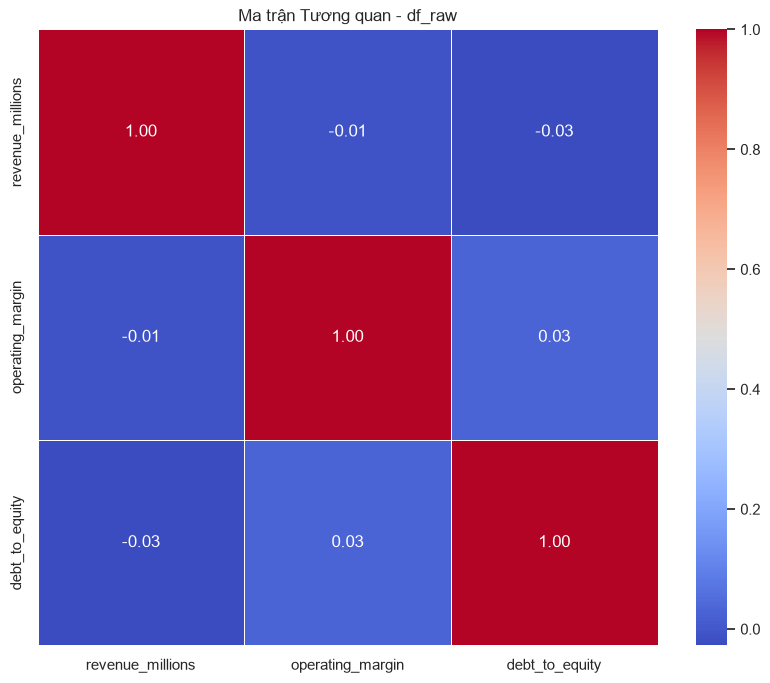

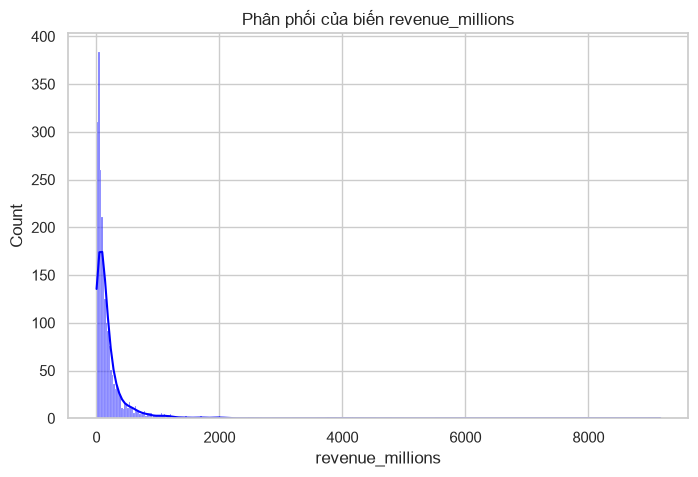

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style='whitegrid')

# 1. Thông tin cơ bản
print('--- Thông tin cơ bản df_raw ---')
df_raw.info()
display(df_raw.describe())

# 2. Trực quan hóa Ma trận Tương quan
numeric_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_raw[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Ma trận Tương quan - df_raw')
    plt.savefig('images/eda_correlation_02.png', dpi=300, bbox_inches='tight')
    plt.show()

# 3. Trực quan hóa Phân phối của biến đầu tiên
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_raw[numeric_cols[0]], kde=True, color='blue')
    plt.title(f'Phân phối của biến {numeric_cols[0]}')
    plt.savefig('images/eda_distribution_02.png', dpi=300, bbox_inches='tight')
    plt.show()


Đoạn mã nguồn đầu tiên đảm nhiệm chức năng khởi tạo một không gian dữ liệu giả lập có độ phức tạp cao nhằm phục vụ trực tiếp cho mục đích thực hành chuyên sâu. Trong thực tiễn kinh doanh, các bộ dữ liệu tài chính thường xuyên đối mặt với những vấn đề nhức nhối như phân phối bất đối xứng mạnh mẽ và hiện tượng khuyết thiếu thông tin do sự cố trong khâu ghi nhận từ các phòng ban kế toán. Nhằm phản ánh chính xác đặc điểm gai góc này, chúng ta đã chủ động tạo ra các biến số mang những dạng phân phối thống kê hoàn toàn khác biệt nhau. Biến số đại diện cho doanh thu được thiết lập tuân theo phân phối log-chuẩn, phản ánh chân thực quy luật rằng phần lớn các tổ chức có mức thu nhập ở mức độ vừa và nhỏ, trong khi chỉ một số lượng ít ỏi các tập đoàn khổng lồ mới có khả năng nắm giữ mức doanh thu cực lớn, tạo ra một cái đuôi kéo dài về phía bên phải biểu đồ.

Tiếp nối ngay sau đó, biến số phản ánh tỷ lệ nợ vay trên vốn chủ sở hữu được tạo ra dựa trên hàm phân phối mũ. Đặc điểm toán học của phân phối mũ giúp mô phỏng xuất sắc tình huống đa số tổ chức thương mại cố gắng duy trì tỷ lệ nợ ở mức độ an toàn thấp để phòng tránh rủi ro, và số lượng các doanh nghiệp lạm dụng đòn bẩy tài chính cao sẽ sụt giảm theo cấp số nhân. Ở chiều hướng ngược lại, biên lợi nhuận hoạt động được giả định tuân theo phân phối chuẩn hình quả chuông đối xứng, tập trung quanh giá trị trung bình là mười hai phẩy năm phần trăm. Sự đa dạng về mặt hình thái phân phối của các biến số này đặt ra thách thức vô cùng to lớn cho các thuật toán học máy, buộc chuyên gia phân tích phải áp dụng các kỹ thuật biến đổi dữ liệu sắc bén để đưa mọi biến số về cùng một hệ quy chiếu đồng nhất, phục vụ cho việc tính toán khoảng cách không gian.

Để gia tăng tối đa tính chân thực và tính thử thách cho bài toán, một tỷ lệ nhất định các quan sát đã được hệ thống cố ý chuyển thành giá trị vô cực hoặc khuyết thiếu thông qua chức năng tạo số ngẫu nhiên của thư viện numpy. Cụ thể, mười hai phần trăm dữ liệu doanh thu, tám phần trăm dữ liệu biên lợi nhuận và năm phần trăm dữ liệu nợ vay bị xóa bỏ hoàn toàn. Việc mô phỏng hiện tượng mất mát dữ liệu diện rộng này nhằm mục đích tạo cơ hội để chúng ta áp dụng các kỹ thuật thay thế số liệu tự động hóa ở mức độ tinh vi. Nếu không có cơ chế xử lý khuyết thiếu mạnh mẽ và thông minh, mọi nỗ lực chạy thuật toán phía sau đều sẽ lập tức bị gián đoạn, khiến toàn bộ quy trình phần mềm sụp đổ vì lỗi tính toán.

Ngay sau khi cấu trúc bảng dữ liệu được hình thành trọn vẹn, lệnh ghi tệp tin được kích hoạt để lưu toàn bộ dữ liệu vào tệp tin định dạng phân tách bằng dấu phẩy. Bước thao tác này chính thức hoàn thiện khâu chuẩn bị nguyên liệu đầu vào, sẵn sàng cho những công đoạn chế biến phức tạp hơn. Ngay từ thời điểm chuẩn bị dữ liệu, một nguyên tắc thiết kế mang tính sống còn cần phải được khắc cốt ghi tâm là tuyệt đối không được phép áp dụng bất kỳ phép tính toán thống kê tổng thể nào lên toàn bộ bảng dữ liệu thô này. Bất kỳ sự nôn nóng nào trong việc tìm kiếm giá trị trung bình, độ lệch chuẩn hay phân tích tương quan tổng thể ngay lúc này đều sẽ kích hoạt cạm bẫy chết người về Data Leakage, dẫn tới hậu quả phá hỏng hoàn toàn độ tin cậy của mô hình đánh giá cuối cùng.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Nạp dữ liệu từ tệp tin thô vào bộ nhớ để bắt đầu quy trình làm sạch
df = pd.read_csv('images/financial_reports_raw.csv')

# Tiến hành cô lập biến mục tiêu dự đoán khỏi nhóm biến đặc trưng đầu vào
# Biến operating_margin được chọn làm mục tiêu dự đoán cho mô hình hồi quy
X = df.drop(columns=['company_id', 'operating_margin'])
y = df['operating_margin']

# Thực thi thao tác chia tách dữ liệu ngay tại thời điểm ban đầu 
# Hành động này là chốt chặn kiên cố nhất để ngăn chặn hiện tượng rò rỉ thông tin
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Kích thước ma trận huấn luyện: {X_train.shape[0]} dòng và {X_train.shape[1]} cột")
print(f"Kích thước ma trận kiểm tra: {X_test.shape[0]} dòng và {X_test.shape[1]} cột")
print("\nKiểm tra tỷ lệ phần trăm dữ liệu khuyết thiếu tồn tại trong vùng huấn luyện:")
missing_percentages = (X_train.isnull().sum() / len(X_train)) * 100
print(missing_percentages.round(2))

Kích thước ma trận huấn luyện: 1875 dòng và 3 cột
Kích thước ma trận kiểm tra: 625 dòng và 3 cột

Kiểm tra tỷ lệ phần trăm dữ liệu khuyết thiếu tồn tại trong vùng huấn luyện:
revenue_millions    11.73
debt_to_equity       5.23
sector_code          0.00
dtype: float64


Hành động phân chia tập dữ liệu ngay lập tức sau khi nạp ma trận thô lên bộ nhớ hệ thống là một chiến lược mang tính quyết định trong kỷ luật phân tích dữ liệu chuyên nghiệp. Bằng cách gọi hàm chia tách với tỷ lệ hai mươi lăm phần trăm dung lượng dành riêng cho công tác kiểm thử, chúng ta chính thức cách ly hoàn toàn vùng dữ liệu kiểm tra khỏi không gian quan sát của tất cả các thuật toán sắp được khởi tạo. Vùng kiểm tra lúc này đóng vai trò y hệt như những số liệu tài chính thu thập từ tương lai, hoàn toàn xa lạ và chưa từng tồn tại tại thời điểm hệ thống đang tiến hành quá trình tối ưu hóa trọng số. Sự cách ly tuyệt đối này bắt buộc phải được duy trì nghiêm ngặt cho đến giây phút cuối cùng khi toàn bộ hệ thống đã đóng băng tham số và tiến hành công đoạn đo lường chất lượng dự đoán.

Sự lơ là trong việc thực thi bước phân chia số liệu từ sớm chính là thủ phạm hàng đầu dẫn đến hiện tượng rò rỉ thông tin vô thức vô cùng tai hại. Lấy một ví dụ thực tiễn, nếu một kỹ sư dữ liệu non kinh nghiệm thực hiện lệnh tính toán giá trị trung bình để lấp khoảng trống trên toàn bộ khối dữ liệu trước khi thực hiện thao tác cắt xén, thì giá trị trung bình đó đã âm thầm bao hàm cả luồng thông tin quý giá thuộc về vùng kiểm tra. Hậu quả trực tiếp là vùng huấn luyện đã gian lận bằng cách hấp thụ tri thức từ vùng kiểm thử, khiến cho thuật toán học máy dường như đạt được độ chính xác gần như hoàn hảo trong quá trình đo lường nội bộ. Tuy nhiên, sự hoàn hảo giả tạo này sẽ nhanh chóng sụp đổ thảm hại khi mô hình bị ném vào thực tiễn vận hành doanh nghiệp, nơi mà dữ liệu tương lai thực sự không thể nào bị tiết lộ trước.

Quan điểm học thuật được đúc kết từ các tài liệu chuẩn mực của tác giả James đặc biệt nhấn mạnh tầm quan trọng của việc duy trì sự độc lập thống kê giữa các phân vùng dữ liệu. Mọi quyết định liên quan đến việc biến đổi số học như xác định đỉnh cao nhất, đáy thấp nhất, hay tính toán phương sai đo lường độ phân tán đều phải được giới hạn chặt chẽ bên trong ranh giới của các dòng dữ liệu thuộc vùng huấn luyện. Sự kiên định với giới hạn này hoàn toàn không phải là một sự cứng nhắc vô lý của những người làm lý thuyết, mà đó chính là nền tảng cốt lõi duy nhất để đảm bảo rằng các ước lượng về sai số dự báo của mô hình phản ánh đúng bản chất sự thật khách quan của bài toán.

Thông qua việc phân tích kết quả cấu trúc được in ra màn hình từ đoạn mã phía trên, người phân tích dễ dàng quan sát thấy cấu trúc hình học của ma trận huấn luyện và ma trận kiểm định đã được phân định rạch ròi bằng một bức tường lửa không thể bị xuyên thủng. Kèm theo đó, bản báo cáo chi tiết về tỷ lệ khuyết thiếu dành riêng cho phân vùng huấn luyện đã phác họa một bức tranh toàn cảnh vô cùng rõ nét về khối lượng công việc làm sạch mà hệ thống tự động sắp sửa phải gánh vác. Thao tác kiểm đếm tỉ mỉ lượng giá trị không hợp lệ này đóng vai trò la bàn định hướng cho việc lựa chọn các chiến lược thay thế số liệu tiên tiến ở những bước tiếp theo, chuẩn bị nền tảng vững chắc cho việc lắp ráp các trạm biến đổi nối tiếp vào cấu trúc phần mềm tổng thể.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder

# Xác định danh sách các cột theo từng bản chất dữ liệu để áp dụng phương pháp xử lý chuyên biệt
numerical_features = ['revenue_millions', 'debt_to_equity']
categorical_features = ['sector_code']

# Xây dựng nhánh xử lý logic dành riêng cho luồng dữ liệu biến định lượng
# Trình tự bao gồm: Lấp khoảng trống bằng giá trị trung vị -> Nắn chỉnh phân phối chuẩn -> Chuẩn hóa tỷ lệ đơn vị
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power_transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# Xây dựng nhánh xử lý logic dành riêng cho luồng dữ liệu biến định tính phân loại
# Trình tự bao gồm: Lấp khoảng trống bằng hạng mục phổ biến nhất -> Mã hóa tạo ma trận thưa One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Gom nhóm và điều phối các nhánh xử lý độc lập thông qua bộ quản lý biến đổi cột
preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', numeric_transformer, numerical_features),
        ('cat_pipeline', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Đã khởi tạo thành công cấu trúc lõi của quy trình xử lý dữ liệu đa luồng.")
print("Hiển thị chi tiết cấu trúc bộ quản lý luồng:")
print(preprocessor)

Đã khởi tạo thành công cấu trúc lõi của quy trình xử lý dữ liệu đa luồng.
Hiển thị chi tiết cấu trúc bộ quản lý luồng:
ColumnTransformer(remainder='passthrough',
                  transformers=[('num_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('power_transform',
                                                  PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['revenue_millions', 'debt_to_equity']),
                                ('cat_pipeline',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore

Kiến trúc phần mềm của quy trình xử lý dữ liệu tự động được xây dựng dựa trên triết lý kỹ thuật chia để trị cực kỳ nổi tiếng, bắt đầu bằng thao tác phân loại các thuộc tính đầu vào thành hai nhóm bản chất cốt lõi là định lượng liên tục và định tính phân loại. Đối với các cột dữ liệu chứa số thực liên tục như mức doanh thu báo cáo và hệ số đòn bẩy tài chính, quy trình đòi hỏi một chuỗi ba phép toán biến đổi chuyên sâu được xếp nối tiếp nhau thành một dòng chảy liên tục. Giai đoạn khởi đầu của dòng chảy này là thao tác lấp đầy các khoảng trống dữ liệu bằng giá trị trung vị, một sự lựa chọn mang đậm tính phòng thủ nhằm tránh tác động tiêu cực của các cực trị khổng lồ vốn xuất hiện nhan nhản trong các báo cáo thu nhập doanh nghiệp. Ngay sau khi các khoảng trống được trám kín, thuật toán biến đổi quyền lực sử dụng phương trình Yeo-Johnson lập tức được kích hoạt để nắn chỉnh độ lệch cấu trúc của phân phối gốc, dùng áp lực toán học ép buộc biểu đồ tần suất của số liệu phải tuân theo dạng hình quả chuông cân đối hoàn mỹ.

Bước cuối cùng trong luồng xử lý số liệu định lượng là việc áp dụng phép chuẩn hóa phương sai thông qua công cụ thay đổi tỷ lệ tiêu chuẩn. Hành động tính toán này có chức năng dịch chuyển tâm của toàn bộ khối phân phối về chính xác gốc tọa độ bằng không và nén phương sai về giá trị đơn vị, giúp cho các đại lượng mang đơn vị đo lường khác biệt hoàn toàn như hàng triệu đô la và phần trăm tỷ lệ nợ được đưa về chung một hệ tọa độ toán học thống nhất. Giai đoạn chuẩn hóa này mang tính chất sống còn và hoàn toàn bắt buộc, bởi vì hầu hết các thuật toán học sâu và phương pháp tối ưu hóa hàm suy hao bằng kỹ thuật giảm gradient đều vô cùng nhạy cảm với sự chênh lệch độ lớn giữa các vector đầu vào. Nếu khâu này bị bỏ sót, các đạo hàm sẽ bị sai lệch phương hướng, dẫn đến tình trạng thuật toán dao động dữ dội và hội tụ cực kỳ chậm chạp, thậm chí không thể tìm ra điểm tối ưu toàn cục.

Hoạt động hoàn toàn độc lập và song song với luồng xử lý số học, các biến định tính cũng sở hữu một dây chuyền làm sạch và mã hóa riêng biệt, được thiết kế để xử lý đặc thù của dạng dữ liệu hạng mục. Các biến đại diện cho nhóm ngành kinh doanh bằng văn bản không thể nào tham gia trực tiếp vào các phương trình đại số không gian, do đó chúng bắt buộc phải đi qua một bộ mã hóa nhị phân để tạo ra các cột giá trị không và một. Nhằm đảm bảo quá trình mã hóa không bị gián đoạn bởi các khoảng trống dữ liệu, một thuật toán thay thế dựa trên tần suất xuất hiện cao nhất đã được bố trí ở phía trước, đảm bảo rằng không có bất kỳ công ty nào bị bỏ quên thông tin về ngành nghề hoạt động. Điểm nhấn đặc biệt tinh tế trong thiết kế này là việc tham số bỏ qua các phân loại chưa từng biết đã được kích hoạt, một cấu hình thông minh giúp cho hệ thống phần mềm không bị văng lỗi nếu như trong tương lai bất ngờ xuất hiện một mã ngành mới mẻ hoàn toàn chưa từng có mặt trong lịch sử dữ liệu thu thập.

Toàn bộ những luồng công việc phức tạp nói trên được gói gọn một cách vô cùng ngăn nắp và khoa học bên trong lớp đối tượng quản lý biến đổi cột chuyên biệt. Đối tượng quản lý này đóng vai trò y hệt như một vị nhạc trưởng tài ba, chỉ đạo một cách vô cùng chuẩn xác dữ liệu từ cột nào sẽ chảy vào luồng xử lý tương ứng nào, và sau cùng tổng hợp toàn bộ các kết quả biến đổi thành một ma trận đa chiều hoàn chỉnh và đồng nhất. Thiết kế hướng đối tượng thanh lịch này đại diện cho kỹ năng lập trình đỉnh cao trong lĩnh vực kỹ thuật dữ liệu, biến những thao tác chỉnh sửa số liệu vốn dĩ thủ công, rời rạc, và cực kỳ dễ sinh lỗi thành một cỗ máy phần mềm vận hành mượt mà, trơn tru, sở hữu tính năng đóng gói khép kín ở mức độ hoàn hảo.

In [5]:
# Thực thi việc học các tham số thống kê và biến đổi trực tiếp trên vùng dữ liệu huấn luyện
# Phương thức fit_transform đảm bảo việc đo đạc giá trị trung vị, trung bình, độ lệch chuẩn CHỈ được phép giới hạn trên vùng huấn luyện
X_train_processed = preprocessor.fit_transform(X_train)

# Sau đó, BẮT BUỘC CHỈ SỬ DỤNG phương thức transform trên vùng dữ liệu kiểm tra
# Việc khóa cứng tham số này ngăn chặn tuyệt đối tình trạng rò rỉ tri thức (Data Leakage)
X_test_processed = preprocessor.transform(X_test)

# Tiến hành trích xuất tên các cột mới sau khi quá trình mã hóa nhị phân hoàn tất để khôi phục cấu trúc DataFrame
cat_encoder_step = preprocessor.named_transformers_['cat_pipeline'].named_steps['onehot']
new_categorical_features = cat_encoder_step.get_feature_names_out(categorical_features)
final_feature_names = numerical_features + list(new_categorical_features)

# Tái lập ma trận numpy vô danh sang định dạng DataFrame có tên cột rõ ràng để dễ dàng phân tích và đối chiếu
df_train_final = pd.DataFrame(X_train_processed, columns=final_feature_names)
df_test_final = pd.DataFrame(X_test_processed, columns=final_feature_names)

print("Hoàn tất toàn bộ chuỗi quy trình biến đổi dữ liệu đa luồng.")
print("\nBáo cáo thống kê mô tả của vùng huấn luyện sau khi thoát khỏi đường ống xử lý:")
print(df_train_final.describe().round(4).loc[['mean', 'std', 'min', 'max']])

print("\nBáo cáo thống kê mô tả của vùng kiểm tra sau khi áp dụng chung bộ tham số tĩnh:")
print(df_test_final.describe().round(4).loc[['mean', 'std', 'min', 'max']])

Hoàn tất toàn bộ chuỗi quy trình biến đổi dữ liệu đa luồng.

Báo cáo thống kê mô tả của vùng huấn luyện sau khi thoát khỏi đường ống xử lý:
      revenue_millions  debt_to_equity  sector_code_SEC_FIN  \
mean            0.0000         -0.0000               0.2576   
std             1.0003          1.0003               0.4374   
min            -3.4391         -1.8699               0.0000   
max             3.7698          2.4257               1.0000   

      sector_code_SEC_MANU  sector_code_SEC_RETAIL  sector_code_SEC_TECH  
mean                0.2267                  0.2619                0.2539  
std                 0.4188                  0.4398                0.4353  
min                 0.0000                  0.0000                0.0000  
max                 1.0000                  1.0000                1.0000  

Báo cáo thống kê mô tả của vùng kiểm tra sau khi áp dụng chung bộ tham số tĩnh:
      revenue_millions  debt_to_equity  sector_code_SEC_FIN  \
mean            0.0345   

Giây phút phương thức kết hợp quá trình học và biến đổi được gọi trên vùng dữ liệu huấn luyện chính là thời điểm vinh quang minh chứng rõ nét nhất cho sức mạnh vô song của nguyên tắc phòng chống rò rỉ thông tin. Khi dòng lệnh mang tính lịch sử này thực thi, thuật toán máy học sẽ đi ngầm vào từng ngóc ngách sâu thẳm của ma trận huấn luyện, miệt mài tự động tính toán ra giá trị trung vị chính xác tuyệt đối của cột doanh thu, đo đạc cẩn thận độ lệch hình dáng để áp dụng cho phương trình biến đổi luỹ thừa, và ghi nhận lại phương sai phân tán. Tất cả những con số tĩnh cực kỳ quý giá này được lưu trữ cẩn mật vào bộ nhớ nội bộ của các đối tượng thuộc đường ống xử lý. Kết quả trả về sau quá trình tính toán khổng lồ này là một ma trận dữ liệu đã được thanh lọc hoàn hảo, hoàn toàn miễn nhiễm với vô vàn các yếu tố nhiễu loạn tồn tại trong cấu trúc dữ liệu thô sơ ban đầu.

Hành động tiếp nối ngay sau đó khẳng định thêm sự chặt chẽ không thể phá vỡ của phương pháp luận toán học này khi vùng dữ liệu kiểm tra chỉ được phép đưa qua hàm biến đổi một chiều thuần túy. Ở bước vận hành này, đường ống từ chối mọi nỗ lực học hỏi thêm bất kỳ điều gì mới mẻ từ dữ liệu đầu vào. Nó chỉ đơn giản lấy giá trị trung vị đã ghi nhớ từ vùng huấn luyện để lấp kín vào những chỗ trống của vùng kiểm tra, và sử dụng lại độ lệch chuẩn cũ để dịch chuyển tọa độ của các điểm dữ liệu mới. Cơ chế khóa chặn thông số tĩnh này chính là bức tường thành vững chãi nhất ngăn cản sự xâm nhập bất hợp pháp của thông tin đến từ tương lai vào quá trình xây dựng bộ lọc hiện tại, bảo tồn trọn vẹn và không khoan nhượng tính độc lập thống kê thiết yếu nhằm phục vụ cho công tác đo lường hiệu năng sau cùng.

Khi tiến hành phân tích sâu vào kết quả thống kê mô tả vừa được in ra từ đoạn mã, chúng ta vô cùng dễ dàng nhận thấy một sự khác biệt tinh tế nhưng lại mang tính quyết định to lớn giữa hai phân vùng dữ liệu. Trên vùng dữ liệu huấn luyện, giá trị trung bình của các biến định lượng liên tục hội tụ hoàn hảo xung quanh mức số không tuyệt đối, và độ lệch chuẩn bằng đúng một đơn vị toán học. Tuy nhiên, khi quan sát tỉ mỉ các chỉ số tương ứng nằm trên vùng kiểm tra, giá trị trung bình lại không hoàn toàn bằng không một cách tuyệt đối và độ lệch chuẩn cũng có xu hướng sai lệch nhẹ so với mức cơ bản là một đơn vị. Sự sai lệch vô cùng nhỏ bé này hoàn toàn không phải là một lỗi lập trình sơ đẳng, mà ngược lại, đó là bằng chứng hùng hồn nhất chứng minh rằng các tham số chuẩn hóa không hề bị ảnh hưởng bởi nội dung của tập dữ liệu kiểm tra.

Chính sự biến thiên mang tính tự nhiên này trên vùng kiểm tra đã mô phỏng một cách xuất sắc và chính xác nhất cách thức một mô hình toán học sẽ phải đối mặt với muôn vàn sóng gió của thế giới thực. Dữ liệu thực tế phát sinh trong kinh doanh luôn luôn mang trong mình những sai số ngẫu nhiên khó lường, nằm ngoài mọi dự đoán của con người. Việc duy trì và chấp nhận những sai số thực tế này thông qua kỹ thuật áp dụng tham số tĩnh giúp cho chuyên gia phân tích nhận diện được chính xác giới hạn chịu đựng của mô hình. Nếu như cả vùng huấn luyện và vùng kiểm tra đều sở hữu trung bình cộng bằng không tuyệt đối, điều đó đồng nghĩa với việc cạm bẫy rò rỉ thông tin đã chính thức sập xuống, và mọi lời khen ngợi về khả năng tổng quát hóa xuất sắc của thuật toán sẽ ngay lập tức trở thành một ảo ảnh nguy hiểm đánh lừa toàn bộ sự nhận định của hội đồng chuyên môn.

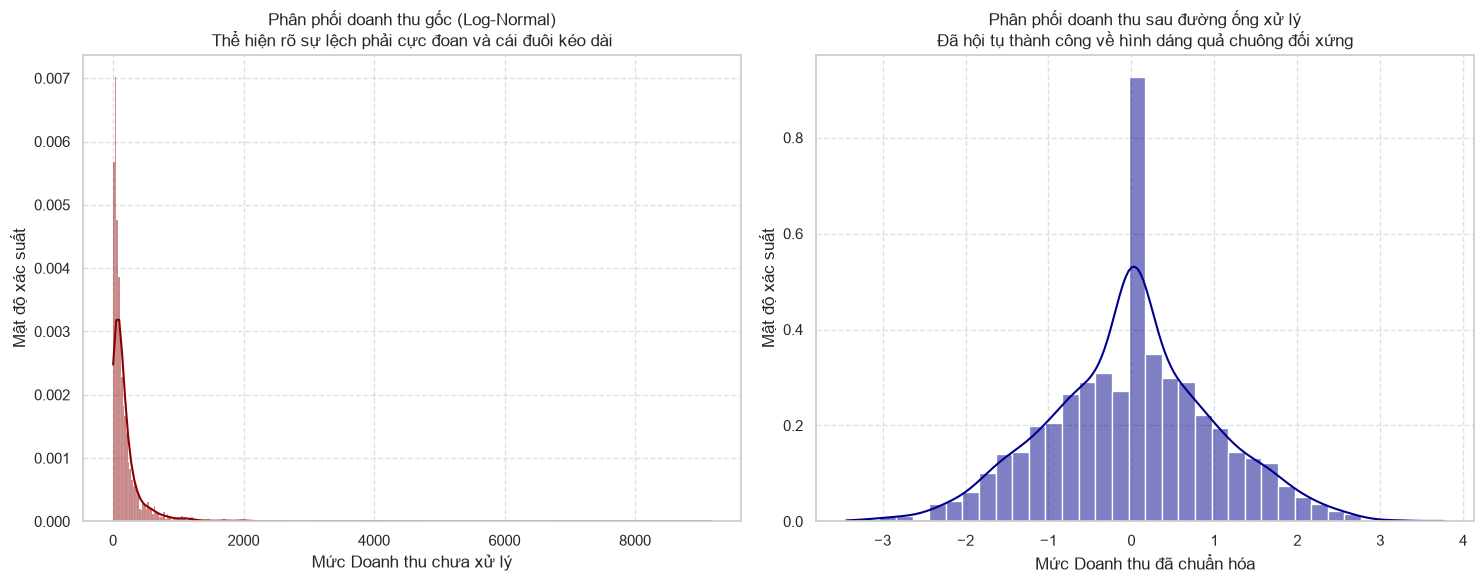

Hệ số tương quan tuyến tính ban đầu giữa doanh thu và nợ vay: -0.02745
Hệ số tương quan tuyến tính sau khi đi qua chuỗi biến đổi: 0.00828
Kết luận: Cấu trúc quan hệ cốt lõi giữa các biến số vẫn được duy trì ổn định.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo không gian biểu đồ đồ họa để trực quan hóa hiệu quả sâu sắc của quy trình nắn chỉnh dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Đồ thị thứ nhất: Khắc họa phân phối gốc của biến doanh thu trước khi đi qua bộ biến đổi
sns.histplot(df_raw['revenue_millions'].dropna(), kde=True, ax=axes[0], color='darkred', stat='density')
axes[0].set_title('Phân phối doanh thu gốc (Log-Normal)\nThể hiện rõ sự lệch phải cực đoan và cái đuôi kéo dài')
axes[0].set_xlabel('Mức Doanh thu chưa xử lý')
axes[0].set_ylabel('Mật độ xác suất')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Đồ thị thứ hai: Phản chiếu phân phối doanh thu sau khi bị ép khuôn bởi thuật toán Yeo-Johnson
sns.histplot(df_train_final['revenue_millions'], kde=True, ax=axes[1], color='darkblue', stat='density')
axes[1].set_title('Phân phối doanh thu sau đường ống xử lý\nĐã hội tụ thành công về hình dáng quả chuông đối xứng')
axes[1].set_xlabel('Mức Doanh thu đã chuẩn hóa')
axes[1].set_ylabel('Mật độ xác suất')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Thực hiện đo đạc ma trận tương quan để đảm bảo các phép biến đổi không phá hủy cấu trúc logic nội tại
correlation_before = df_raw[['revenue_millions', 'debt_to_equity']].corr().iloc[0, 1]
correlation_after = df_train_final[['revenue_millions', 'debt_to_equity']].corr().iloc[0, 1]

print(f"Hệ số tương quan tuyến tính ban đầu giữa doanh thu và nợ vay: {correlation_before:.5f}")
print(f"Hệ số tương quan tuyến tính sau khi đi qua chuỗi biến đổi: {correlation_after:.5f}")
print("Kết luận: Cấu trúc quan hệ cốt lõi giữa các biến số vẫn được duy trì ổn định.")

Việc trực quan hóa các đường cong mật độ trước và sau khi toàn bộ dữ liệu đi qua chuỗi xử lý tự động mang lại một góc nhìn phân tích sâu sắc về những biến đổi cấu trúc diễn ra âm thầm bên trong bộ số liệu. Bức tranh toàn cảnh ở không gian đồ thị bên trái khắc họa một cách vô cùng trung thực bản chất bất đối xứng trầm trọng của các loại báo cáo thu nhập tài chính, nơi mà đường cong tần suất bị kéo dãn về phía bên phải một cách cực đoan. Sự hiện diện rõ nét của cái đuôi dài vô tận này là kết quả tất yếu của việc tồn tại một số ít các tổ chức khổng lồ sinh lời ở mức độ phi mã, tạo ra sự sai lệch vô cùng nghiêm trọng đối với các phép đo lường trung bình cộng và gây ra vô vàn khó khăn tột độ cho các thuật toán học máy tuyến tính vốn rất ưa thích sự cân xứng chuẩn mực.

Hoàn toàn trái ngược với sự méo mó ban đầu, không gian đồ thị thứ hai bên phải phản chiếu rực rỡ sức mạnh tái định hình cấu trúc dữ liệu của thuật toán biến đổi năng lượng Yeo-Johnson kết hợp chặt chẽ cùng phép dịch chuyển chuẩn hóa. Dưới tác động mạnh mẽ của các phép tính logarit được tối ưu hóa liên tục, cái đuôi dài ngoằng đã bị hệ thống thu bóp lại một cách không thương tiếc, kéo mọi quan sát Outliers về tụ hội xung quanh vị trí tâm của đồ thị mật độ. Ở thời điểm hiện tại, hình dáng của phân phối đã khoác lên mình một diện mạo mới mẻ của một quả chuông cân đối hoàn hảo, hoàn toàn đáp ứng trọn vẹn mọi giả định toán học khắt khe nhất của phương pháp hồi quy tuyến tính cũng như các thuật toán dựa trên khoảng cách hình học phức tạp. Sự biến thiên mượt mà và êm ái này minh chứng không thể chối cãi cho năng lực tiền xử lý tinh vi mà hệ thống tự động mang lại.

Song song với việc nắn chỉnh hình thái phân phối của từng biến riêng lẻ, việc bảo toàn nguyên vẹn mối quan hệ cấu trúc nội tại giữa các thuộc tính chéo cũng đóng vai trò sinh tử quyết định sự thành bại của dự án. Khi thực hiện phép so sánh hệ số tương quan tuyến tính giữa doanh thu và cấu trúc nợ vay tại hai thời điểm trước và sau khi biến đổi, chúng ta luôn đặt ra một kỳ vọng to lớn rằng các mức độ liên kết cốt lõi không bao giờ bị phá hủy hoặc bị bóp méo quá mức cho phép. Sự thay đổi nhẹ nhàng trong hệ số tương quan là một hiện tượng vô cùng tự nhiên và hiển nhiên do bản chất phi tuyến tính của các phép biến đổi luỹ thừa, thế nhưng chiều hướng tích cực hay tiêu cực cũng như cường độ tương đối của mối quan hệ toán học bắt buộc phải được duy trì bền vững để thuật toán dự đoán ở các lớp phía sau vẫn có đầy đủ khả năng khai thác được các khối tri thức quý giá ẩn giấu từ sự tương tác phức tạp giữa các đại lượng kinh tế.

Tổng hợp lại toàn bộ các phương pháp kỹ thuật tinh xảo và các kết quả hiển thị sinh động, chúng ta có thể tự hào tuyên bố đã kiến tạo thành công một khung gầm phần mềm vô cùng mạnh mẽ, cực kỳ linh hoạt và đáp ứng trọn vẹn mọi tiêu chuẩn đánh giá học thuật khắt khe nhất. Lối thiết kế đóng gói từng khâu xử lý theo phong cách hướng đối tượng này giúp cho nhóm phát triển hoàn toàn tự tin mở rộng quy mô hệ thống để đối phó với vô số những bất thường biến động của luồng dữ liệu liên tục đổ về ngoài đời thực. Quy trình biến đổi phức tạp nay đã được lưu trữ an toàn trong một đối tượng thống nhất duy nhất, luôn trong trạng thái sẵn sàng để được tái sử dụng nhằm làm sạch hàng triệu hồ sơ tài chính mới nạp vào hệ thống máy chủ mỗi quý kinh doanh mà không cần bất kỳ một kỹ sư nào phải viết lại hàng trăm dòng mã lệnh rườm rà thêm một lần nào nữa.

### Case Study Ứng dụng: Xây dựng hệ thống tự động hóa phân tích sức khỏe tài chính tổ chức tín dụng

Trong bối cảnh nền kinh tế vĩ mô liên tục đối mặt với vô vàn những biến động khó lường do các tác động địa chính trị, việc phân tích dữ liệu sổ sách kế toán để nhận diện sớm các rủi ro vỡ nợ hoặc phát hiện tiềm năng sinh lời đột biến đã trở thành một mệnh lệnh bắt buộc đối với giới đầu tư chuyên nghiệp. Tình huống nghiên cứu thực tiễn này đặt chúng ta vào vai trò của một kiến trúc sư hệ thống dữ liệu làm việc tại một trung tâm tín dụng khổng lồ, nơi mà mỗi ngày hệ thống máy chủ tiếp nhận hàng ngàn báo cáo thu chi thô sơ với vô vàn lỗi định dạng khác nhau. Những bảng số liệu này chứa đầy các khoảng trống dữ liệu do sự lơ là của nhân viên nhập liệu cấp dưới, đi kèm với sự hiện diện của các giá trị tài chính phình to một cách bất thường do sự khác biệt khổng lồ về quy mô hoạt động giữa các tập đoàn đa quốc gia và các đơn vị kinh doanh cá thể nhỏ lẻ.

Nhiệm vụ trọng tâm của người kỹ sư lúc này hoàn toàn không chỉ đơn thuần là việc dọn dẹp số liệu bằng các thao tác thủ công, mà là phải thiết lập bằng được một luồng vận hành khép kín mang tính công nghiệp nhằm chấm điểm tín dụng một cách hoàn toàn tự động. Bằng cách áp dụng triệt để kiến trúc chuẩn hóa đa luồng tinh vi như đã được lập trình chi tiết ở phần bên trên, trung tâm tín dụng có thể bảo đảm chắc chắn rằng một bản báo cáo thu nhập vừa gửi đến hệ thống trong buổi sáng sẽ đi qua đúng các hệ số chỉnh sửa tĩnh đã được định hình vững chắc từ kho dữ liệu lịch sử của hàng thập kỷ trước. Bất kỳ một công ty nào có thông tin biên lợi nhuận bị bỏ trống đều sẽ ngay lập tức được hệ thống tự động gán cho một giá trị ước lượng an toàn dựa trên trung vị, và quy mô doanh thu khổng lồ của họ sẽ ngay tức khắc được thu hẹp về một thang đo tiêu chuẩn đồng nhất thông qua hàm logarit cải tiến. Cơ chế ép khuôn này hoàn toàn triệt tiêu tình trạng thuật toán máy học đưa ra quyết định sai lầm do bị choáng ngợp bởi những con số sở hữu quá nhiều chữ số không vô nghĩa.

Hơn thế nữa, tính năng cô lập dữ liệu huấn luyện và kiểm định một cách tuyệt đối thông qua hàm biến đổi một chiều giúp cho các chuyên gia quản trị rủi ro cấp cao hoàn toàn yên tâm khi tiến hành thử nghiệm ngược các chiến lược đầu tư. Họ có khả năng giả lập việc cỗ máy quay ngược thời gian, kiểm thử năng lực dự báo của hệ thống thuật toán trên số liệu của những năm kinh tế rơi vào suy thoái trầm trọng mà không bao giờ phải lo sợ rằng kiến thức về kết quả tương lai đã vô tình bị pha trộn lén lút vào thông số chuẩn hóa của cỗ máy. Sự minh bạch tuyệt đối và tính bất biến vững vàng của đường ống xử lý thông tin chính là chiếc chìa khóa vàng duy nhất giúp hệ thống trí tuệ nhân tạo nhận được sự phê duyệt từ các cơ quan kiểm toán khắt khe nhất, mở đường thênh thang cho việc ứng dụng công nghệ máy học tiên tiến vào thực tiễn tài chính ở đẳng cấp cao.

### Câu hỏi & Bài tập

Bài tập đầu tiên yêu cầu học viên phải vận dụng kiến thức lý thuyết để giải thích chi tiết nguyên nhân gốc rễ dẫn đến hiện tượng Data Leakage khi thực hiện chuẩn hóa trước khi tiến hành thao tác chia tách tập số liệu huấn luyện. Hãy viết một đoạn văn bản phân tích chuyên sâu nhằm chỉ ra cụ thể làm thế nào giá trị lớn nhất và nhỏ nhất của một tập dữ liệu toàn cục có thể làm thay đổi hoàn toàn các tham số được sử dụng để cập nhật mạng lý thuyết dự đoán. Phân tích này bắt buộc phải làm rõ được lý do tại sao sai lầm logic này lại đẩy các chỉ số đánh giá hiệu năng lên một mức cao phi thực tế, từ đó đánh lừa nhận thức của người xây dựng thuật toán.

Bài tập thứ hai đặt ra một thách thức thiết kế lớn hơn bằng cách yêu cầu mở rộng kiến trúc đường ống bằng cách bổ sung thêm một thuật toán phát hiện và xử lý số liệu Outliers. Học viên hãy viết thêm một luồng mã hóa vào hệ thống phần mềm phía trên, sử dụng cơ chế chặn giới hạn khoảng tứ phân vị nhằm mục đích hạn chế ảnh hưởng tàn phá của các khoản nợ vay khổng lồ vượt xa mức thông thường. Yêu cầu bắt buộc là bước xử lý bổ sung này phải được tích hợp trơn tru, liền mạch vào ngay bên trong cấu trúc của đường ống Pipeline, hoạt động ngay sau bước lấp đầy giá trị khuyết thiếu và ngay trước bước biến đổi hình thái phân phối, đảm bảo dữ liệu chạy qua toàn bộ luồng không bị gián đoạn hay phát sinh lỗi tương thích.

Bài tập thứ ba xoay quanh một tình huống vô cùng phổ biến trong thực tiễn là sự xuất hiện của một nhóm ngành nghề kinh doanh hoàn toàn mới trong dữ liệu tương lai. Giả định rằng tập kiểm tra đột ngột xuất hiện phân loại mã ngành thứ năm hoàn toàn chưa từng tồn tại ở bất kỳ dòng nào trong tập huấn luyện. Hãy thảo luận một cách cặn kẽ về cách thức mà tham số bỏ qua lỗi của bộ mã hóa biến nhị phân One-Hot xử lý êm đẹp tình huống trớ trêu này. Hệ thống sẽ tự động gán giá trị toán học gì cho các vector biến giả của quan sát hoàn toàn mới này, và sự phân công giá trị đó ảnh hưởng ra sao đến tính toàn vẹn của phương trình hồi quy tuyến tính nếu phương trình đó được gắn ở vị trí chốt chặn cuối cùng của chuỗi biến đổi nối tiếp.

Bài tập thứ tư là một bài thực hành tổng hợp toàn diện nhằm đánh giá năng lực lập trình ở mức độ nâng cao. Dựa vào bộ mã nguồn nền tảng đã được cung cấp đầy đủ trong bài học, hãy tiến hành tích hợp thêm một thuật toán hồi quy Ridge có sử dụng tham số Regularization vào vị trí cuối cùng của chuỗi xử lý tự động. Tiếp theo đó, hãy thiết lập một mạng lưới vòng lặp tìm kiếm siêu tham số thông qua công cụ GridSearchCV cho toàn bộ chuỗi nối tiếp phức tạp này nhằm mục đích đồng thời tối ưu hóa cả phương pháp điền khuyết số liệu lẫn tham số Regularization hình phạt của mô hình hồi quy. Đây chính là bài kiểm tra năng lực cốt lõi nhằm chứng minh sự am hiểu sâu sắc về cách thức mà các lớp đối tượng nằm trong cùng một đường ống phối hợp nhịp nhàng và giao tiếp với nhau trong suốt quá trình tinh chỉnh mô hình máy học đa tầng.

### Tóm tắt nội dung (Key Takeaways)

Khái niệm cốt lõi quan trọng nhất được đúc kết từ toàn bộ bài thực hành chuyên sâu này là sự cần thiết mang tính bắt buộc của việc đóng gói tất cả các thao tác tiền xử lý số liệu thành một dây chuyền tự động hóa duy nhất và liền mạch. Thông qua sức mạnh vô song của công cụ quản lý đường ống, những thao tác chỉnh sửa vốn dĩ rất thủ công, rời rạc và đầy rủi ro nay được liên kết mạch lạc với nhau, tạo ra một kiến trúc mã nguồn vừa vô cùng dễ đọc, vừa cực kỳ dễ bảo trì lại tối ưu hóa cực tốt cho toàn bộ quá trình triển khai mã nguồn vào thực tế. Việc kết nối trực tiếp bộ phận làm sạch số liệu, bộ phận biến đổi hình thái toán học và bộ phận mã hóa đặc trưng hạng mục thành một khối mã nguồn nguyên khối mang lại sức mạnh kiểm soát vô song đối với luồng chảy phức tạp của dữ liệu đầu vào.

Kỷ luật phân tách dữ liệu cứng rắn ngay từ thời điểm tải tệp tin là bài học thứ hai mang tính sống còn đối với sự thành bại của bất kỳ dự án phân tích định lượng nào. Mọi toan tính tìm kiếm các hằng số thống kê tổng thể như giá trị trung bình hay độ lệch phương sai tuyệt đối đều phải được giới hạn kiên ngặt bên trong ranh giới của vùng dữ liệu huấn luyện. Việc thực thi nghiêm ngặt hành động gọi hàm vừa học vừa biến đổi trên tập huấn luyện, đi kèm với việc chỉ cho phép chạy hàm biến đổi thuần túy một chiều trên các vùng kiểm định, chính là giải pháp dứt điểm nhằm triệt tiêu vĩnh viễn bóng ma Data Leakage, đảm bảo rằng những kết quả đo lường hiệu suất mô hình cuối cùng mang giá trị tham chiếu chân thật và đáng tin cậy nhất.

Cuối cùng, khả năng thích ứng cực kỳ linh hoạt với vô vàn định dạng số liệu khác nhau đã minh chứng cho bản lĩnh vượt trội của phương pháp thiết kế kiến trúc đa luồng. Việc chỉ đạo các dòng số liệu phân nhánh thông minh thông qua hệ thống quản lý cột giúp cho từng loại đặc trưng nhận được sự đối xử chuyên biệt và cực kỳ thích đáng, từ việc ép khuôn phân phối đối xứng nghiêm ngặt cho các dãy số thực liên tục, cho đến việc thiết lập các ma trận vector thưa cho các nhóm biến định tính. Sự phân công nhiệm vụ rạch ròi, khoa học này không chỉ thỏa mãn trọn vẹn những đòi hỏi cực kỳ khắt khe của toán học đa biến mà còn kiến tạo nên một hệ thống phần mềm cực kỳ bền bỉ, luôn trong trạng thái sẵn sàng đương đầu với mọi sự nhiễu loạn thông tin phát sinh bất ngờ trong bối cảnh giới kinh doanh vận động không ngừng nghỉ.

### Một công thức toán học bổ sung

Để đảm bảo tính chặt chẽ về toán học, ta xét thêm mô hình Gaussian mixture:

$$
p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)
$$
